In [1]:
# imports

import os
import glob
import matplotlib.pyplot as plt
import numpy as np
import csv
from itertools import chain
import statistics
import re
import pandas as pd
import pickle

# import seaborn as sns
# sns.set_theme(style="darkgrid")

In [ ]:
# exptime = "2025-12-10-09:01:06-c2b51ea35fe9e83e4c32368cba9a362bd7a175d8"
# exptime = "2025-12-11-OSDI-submission"

# --- Zoo 5-machine experiment ---
# Set this to the Zoo result directory name (under results/)
exptime = os.environ.get("ZOO_EXPTIME", "2026-03-23-10:26:07-zoo-5machines")

# Derive project root reliably: notebook lives in scripts/, so go up one level
# This works whether jupyter is launched from scripts/ or the project root
current_dir = os.getcwd()
if os.path.basename(current_dir) == "scripts":
    project_root = os.path.dirname(current_dir)
else:
    project_root = current_dir

directory_path = os.path.join(project_root, "results", exptime)
files = os.listdir(directory_path)
file_names = [file for file in files if os.path.isfile(os.path.join(directory_path, file))]
file_names = [file_name for file_name in file_names if file_name != "rerun.txt"]
print(f"exptime: {exptime}")
print(f"project_root: {project_root}")
print(f"Result files: {len(file_names)}")

In [ ]:
# constants

protocols = [
    ("rule_raft", "none_raft"),
    ("rule_copilot", "none_copilot"),
    ("rule_mencius", "none_mencius"),
    ("rule_mongodb", "none_mongodb"),
    ("rule_etcd", "none_etcd"),
    ("rule_zookeeper", "none_zookeeper"),
]
protocol_name = [
    "Raft",
    "Copilot",
    "Mencius",
    "MongoDB",
    "etcd",
    "ZooKeeper",
]
jetpack_protocols = [x for (x, y) in protocols]
vanilla_protocols = [y for (x, y) in protocols]

sites = ["30c1s5r5p-zoo"]
site_tag = sites[0]  # used in figure filenames
workloads = ["rw_1000000"]
zipf_workloads = ["rw_zipf_1", "rw_zipf_0.9", "rw_zipf_0.8", "rw_zipf_0.7", "rw_zipf_0.6", "rw_zipf_0.5"]
key_range_workloads = ["rw_1", "rw_10", "rw_100", "rw_1000", "rw_10000", "rw_100000", "rw_1000000"]
ycsb_configs = ["YCSB_A"]

conc_number = {
    "none_raft": ["concurrent_" + str(c) for c in [1, 10, 20, 40, 60, 80, 100, 120, 140, 150, 160, 170, 180, 190, 200, 250, 300, 400, 500, 750, 1000]],
    "none_copilot": ["concurrent_" + str(c) for c in [1, 10, 20, 30, 40, 50, 60, 70, 72, 75, 77, 80, 82, 85, 87, 90, 100, 120, 140, 160, 180, 200]],
    "none_mencius": ["concurrent_" + str(c) for c in [1, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40, 45, 50, 55, 60]],
    "none_mongodb": ["concurrent_" + str(c) for c in [1, 10, 20, 30, 35, 40, 50, 60, 70, 80, 90, 100, 110, 120]],
    "none_etcd": ["concurrent_" + str(c) for c in [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]],
    "none_zookeeper": ["concurrent_" + str(c) for c in [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]],
}
for (x, y) in protocols:
    conc_number[x] = conc_number[y]

# Fixed concurrency per protocol — will be updated from fixed_conc.json after experiment 0
fixed_conc_number = {
    "none_raft": "concurrent_140",
    "none_copilot": "concurrent_50",
    "none_mencius": "concurrent_16",
    "none_mongodb": "concurrent_30",
    "none_etcd": "concurrent_30",
    "none_zookeeper": "concurrent_30",
}
contention_fixed_conc_number = dict(fixed_conc_number)  # same for Zoo (single exptime)
for (x, y) in protocols:
    fixed_conc_number[x] = fixed_conc_number[y]
    contention_fixed_conc_number[x] = contention_fixed_conc_number[y]
for name, key in zip(protocol_name, vanilla_protocols):
    fixed_conc_number[name] = fixed_conc_number[key]
    contention_fixed_conc_number[name] = contention_fixed_conc_number[key]

# Try to load fixed_conc.json if it exists (overrides defaults above)
fixed_conc_json = os.path.join(project_root, "results", "fixed_conc.json")
if os.path.exists(fixed_conc_json):
    import json as _json
    with open(fixed_conc_json) as _f:
        _fc = _json.load(_f)
    for proto_key, conc_val in _fc.items():
        fixed_conc_number[proto_key] = conc_val
        contention_fixed_conc_number[proto_key] = conc_val
    # Also set by-name keys
    _name_map = {"none_raft": "Raft", "none_copilot": "Copilot", "none_mencius": "Mencius",
                 "none_mongodb": "MongoDB", "none_etcd": "etcd", "none_zookeeper": "ZooKeeper"}
    for vk, name in _name_map.items():
        if vk in fixed_conc_number:
            fixed_conc_number[name] = fixed_conc_number[vk]
            contention_fixed_conc_number[name] = contention_fixed_conc_number[vk]
    for (x, y) in protocols:
        if y in fixed_conc_number:
            fixed_conc_number[x] = fixed_conc_number[y]
            contention_fixed_conc_number[x] = contention_fixed_conc_number[y]
    print(f"Loaded fixed_conc.json: {_fc}")
else:
    print("No fixed_conc.json found; using default fixed concurrencies")

pcts = ["0", "101", "100"]

latex_constants = {}

# Save figures under the result root (Track 7 requirement)
target_folder = os.path.join(directory_path, "figs") + "/"
tables_folder = os.path.join(directory_path, "tables") + "/"
os.makedirs(target_folder, exist_ok=True)
os.makedirs(tables_folder, exist_ok=True)

default_ycsb = "YCSB_A"

num_leader = {
    "Raft": 1,
    "Copilot": 2,
    "Mencius": 5,
    "MongoDB": 1,
    "etcd": 1,
    "ZooKeeper": 1,
}

In [25]:
# read data from file


rep_server = ["zoo" + str(i) for i in range(5)]
cli_server = ["zoo" + str(i) for i in range(5)]
MAX_RES_SIZE_BYTES = 50 * 1024 * 1024  # res files usually should be ~10MB; skip oversized logs


def analyze_distribution(data):

    data_array = np.array(data)
    data_sorted = np.sort(data_array)
    
    size = data_sorted.size
    pct_50 = np.percentile(data_sorted, 50) if size > 0 else 0
    pct_90 = np.percentile(data_sorted, 90) if size > 0 else 0
    pct_99 = np.percentile(data_sorted, 99) if size > 0 else 0
    average = np.mean(data_sorted) if size > 0 else 0
    
    return size, pct_50, pct_90, pct_99, average


def read_files(*args, directory=None):
    """
    read_files(protocol, site, workload, concurrent, pct, ycsb)
    or
    read_files(file_prefix)

    Optional:
        directory: override base directory (defaults to directory_path)

    Returns:
        ae_cnt, ae_50, ae_90, ae_99, ae_ave,
        throughput, cpu_usage, memory_usage,
        fp_attempt_cnt, fp_success_cnt, fp_efficient_success_cnt,
        fp_success_rate, fp_efficient_success_rate,
        ae, dt, te,
        failure_time, jetpack_recovery_begin_time, jetpack_recovery_end_time
    """
    if len(args) == 1:
        file_prefix = args[0]
    elif len(args) == 6:
        protocol, site, workload, concurrent, pct, ycsb = args
        file_prefix = "-".join([protocol, site, workload, concurrent, pct, ycsb])
    else:
        raise ValueError(
            "read_files() expects either 1 arg (file_prefix) "
            "or 6 args (protocol, site, workload, concurrent, pct, ycsb)"
        )
    print("file_prefix", file_prefix)
    dir_path = directory or directory_path
    
    ae = [[] for _ in range(len(cli_server))]  # All-efficient-attempts per datacenter
    dt = [[] for _ in range(len(cli_server))]  # Dispatch-Time per datacenter
    te = [[] for _ in range(len(cli_server))]  # Time-Elapsed per datacenter

    ae_cnt = {}
    ae_50 = {}
    ae_90 = {}
    ae_99 = {}
    ae_ave = {}
    
    fp_attempt_cnt = {}
    fp_success_cnt = {}
    fp_efficient_success_cnt = {}
    cpu_usage = {}
    memory_usage = {}

    # CPU/memory from replica servers
    for i, server in enumerate(rep_server):
        file_name = os.path.join(dir_path, file_prefix + "-" + server + ".res")
        if os.path.exists(file_name) and os.path.getsize(file_name) > MAX_RES_SIZE_BYTES:
            print(f"Skipping oversized res file (>50MB): {file_name}")
            continue
        try:
            with open(file_name, 'r') as file:
                for line in file:
                    if "server median" in line:
                        parts = line.split('median :')
                        if len(parts) > 1:
                            cpu_usage[i] = float(parts[1].strip())
                    if "memory during test" in line:
                        memory_usage_cur = float(line.split("test: ")[-1].strip())
                        memory_usage[i] = memory_usage_cur
        except FileNotFoundError:
            print(f"Error: The file '{file_name}' does not exist.")

    res_files = []
    for i, server in enumerate(cli_server):
        file_name = os.path.join(dir_path, file_prefix + "-" + server + ".res")
        if os.path.exists(file_name):
            res_files.append(file_name)
        if os.path.exists(file_name) and os.path.getsize(file_name) > MAX_RES_SIZE_BYTES:
            print(f"Skipping oversized res file (>50MB): {file_name}")
            continue
        try:
            with open(file_name, 'r') as file:
                for line in file:
                    if "Fastpath statistics" in line:
                        fp_attempt_cnt[i] = int(line[line.find("attempted")+10:line.find("successed")])
                        fp_success_cnt[i] = int(line[line.find("successed")+10:line.find("rate(pct)")])
                        fp_efficient_success_cnt[i] = int(line[line.find("efficient_successed")+20:line.find("efficient_rate(pct)")])
        except FileNotFoundError:
            print(f"Error: The file '{file_name}' does not exist.")
    
    failure_time = None
    jetpack_recovery_begin_time = None
    jetpack_recovery_end_time = None

    if "failure-recovery" in file_prefix:
        failure_pattern = re.compile(r"paused time=([\d.]+)ms")
        recovery_begin_pattern = re.compile(r"\[JETPACK-RECOVERY\].*STARTING JETPACK RECOVERY.*time=([\d.]+)ms")
        recovery_end_pattern = re.compile(r"\[JETPACK-RECOVERY\].*JETPACK RECOVERY COMPLETED.*time=([\d.]+)ms")

        failure_file = None
        for file_path in res_files:
            if os.path.exists(file_path) and os.path.getsize(file_path) > MAX_RES_SIZE_BYTES:
                print(f"Skipping oversized res file (>50MB): {file_path}")
                continue
            try:
                with open(file_path, 'r') as file:
                    for line in file:
                        failure_match = failure_pattern.search(line)
                        if failure_match:
                            failure_time = float(failure_match.group(1))
                            failure_file = file_path
                            print(failure_file, failure_time, failure_match)
                            break
            except FileNotFoundError:
                print(f"Error: The file '{file_path}' does not exist.")
            if failure_file is not None:
                break

        for file_path in res_files:
            if file_path == failure_file:
                continue
            if os.path.exists(file_path) and os.path.getsize(file_path) > MAX_RES_SIZE_BYTES:
                print(f"Skipping oversized res file (>50MB): {file_path}")
                continue
            try:
                with open(file_path, 'r') as file:
                    for line in file:
                        if jetpack_recovery_begin_time is None:
                            begin_match = recovery_begin_pattern.search(line)
                            if begin_match:
                                jetpack_recovery_begin_time = float(begin_match.group(1))
                                print(file_path, jetpack_recovery_begin_time, begin_match)
                        if jetpack_recovery_end_time is None:
                            end_match = recovery_end_pattern.search(line)
                            if end_match:
                                jetpack_recovery_end_time = float(end_match.group(1))
                                print(file_path, jetpack_recovery_end_time, end_match)
                        if jetpack_recovery_begin_time is not None and jetpack_recovery_end_time is not None:
                            break
            except FileNotFoundError:
                print(f"Error: The file '{file_path}' does not exist.")
            if jetpack_recovery_begin_time is not None and jetpack_recovery_end_time is not None:
                break

    # Read CSVs for latency/dispatch/elapsed
    for i, server in enumerate(cli_server):
        file_name = os.path.join(dir_path, file_prefix + "-" + server + ".csv")
        try:
            with open(file_name, 'r') as file:
                reader = csv.reader(file)
                try:
                    next(reader)  # Skip the header row
                except StopIteration:
                    print("The CSV file is empty.")
                
                for row in reader:
                    if len(row) > 5 and row[5].strip():
                        ae[i].append(float(row[5].strip()))
                    if len(row) > 6 and row[6].strip():
                        dt[i].append(float(row[6].strip()))
                    if len(row) > 7 and row[7].strip():
                        te[i].append(float(row[7].strip()))
        except FileNotFoundError:
            print(f"Error: The file '{file_name}' does not exist.")

        ae_cnt[i], ae_50[i], ae_90[i], ae_99[i], ae_ave[i] = analyze_distribution(ae[i])

    ae_cnt["all"], ae_50["all"], ae_90["all"], ae_99["all"], ae_ave["all"] = analyze_distribution(list(chain.from_iterable(ae)))
    
    throughput = ae_cnt["all"] / 10.0 # divide by 10s
    fp_success_rate = sum(fp_success_cnt.values()) * 100.0 / sum(fp_attempt_cnt.values()) if sum(fp_attempt_cnt.values()) > 0 else 0
    fp_efficient_success_rate = sum(fp_efficient_success_cnt.values()) * 100.0 / sum(fp_attempt_cnt.values()) if sum(fp_attempt_cnt.values()) > 0 else 0
    
    return ae_cnt, ae_50, ae_90, ae_99, ae_ave,             throughput, cpu_usage, memory_usage,             fp_attempt_cnt, fp_success_cnt, fp_efficient_success_cnt, fp_success_rate, fp_efficient_success_rate,             ae, dt, te, failure_time, jetpack_recovery_begin_time, jetpack_recovery_end_time


In [5]:
# for archive and read data

rows = []
data = {}
jetpack_failure_recovery_data = globals().get("jetpack_failure_recovery_data", {})
this_counter = 0

SUMMARY_CACHE_VERSION = 1
SUMMARY_CACHE_PATH = os.path.join(current_dir, "results", exptime + "-summary.pkl")
USE_SUMMARY_CACHE = True
summary_loaded = False

if USE_SUMMARY_CACHE and os.path.exists(SUMMARY_CACHE_PATH):
    try:
        with open(SUMMARY_CACHE_PATH, 'rb') as f:
            cached = pickle.load(f)
        if cached.get("version") == SUMMARY_CACHE_VERSION and cached.get("exptime") == exptime:
            data = cached.get("data", {})
            rows = cached.get("rows", [])
            this_counter = cached.get("this_counter", 0)
            jetpack_failure_recovery_data = cached.get("jetpack_failure_recovery_data", {})
            summary_loaded = True
            print(f"Loaded summary cache from {SUMMARY_CACHE_PATH}")
        else:
            print("Cache version or exptime mismatch; rebuilding summary.")
    except Exception as exc:
        print(f"Failed to load summary cache: {exc}")

SUMMARY_CACHE_LOADED = summary_loaded
SUMMARY_CACHE_NEEDS_SAVE = not summary_loaded
# SUMMARY_CACHE_NEEDS_SAVE = True

if not summary_loaded:
# if True:
    for site in sites:
        data.setdefault(site, {})

        for protocol in vanilla_protocols + jetpack_protocols:
            data.setdefault(site, {})                 .setdefault(protocol, {})
            
            for ycsb in ["YCSB_A"]:
                data.setdefault(site, {})                     .setdefault(protocol, {})                     .setdefault(ycsb, {})
                
                for workload in workloads:
                    data.setdefault(site, {})                         .setdefault(protocol, {})                         .setdefault(ycsb, {})                         .setdefault(workload, {})
                    
                    for pct in ["0"] if protocol in vanilla_protocols else pcts:
                        data.setdefault(site, {})                             .setdefault(protocol, {})                             .setdefault(ycsb, {})                             .setdefault(workload, {})                             .setdefault(pct, {})
                        
                        for concurrent in conc_number[protocol]:
                        # print("protocals: ", protocol, " site: ", site, " workload: ", workload, " concurrent: ", concurrent, " pact: ", pct )
                            ae_cnt, ae_50, ae_90, ae_99, ae_ave,                             throughput, cpu_usage, memory_usage,                             fp_attempt_cnt, fp_success_cnt, fp_efficient_success_cnt, fp_success_rate, fp_efficient_success_rate,                             ae, dt, te, failure_time, jetpack_recovery_begin_time, jetpack_recovery_end_time = read_files(protocol, site, workload, concurrent, pct, ycsb)
                            this_counter += 1
                            if this_counter % 50 == 0:
                                print("progress", this_counter)
                            rows.append([protocol, site, ycsb, workload, concurrent, pct,
                                         ae_cnt["all"], ae_50["all"], ae_90["all"], ae_99["all"], ae_ave["all"],                                         throughput, cpu_usage, memory_usage,                                         fp_attempt_cnt, fp_success_cnt, fp_efficient_success_cnt, fp_success_rate, fp_efficient_success_rate,])
                            
                            data[site][protocol][ycsb][workload][pct][concurrent] = {
                                "ae_cnt": ae_cnt, "ae_50": ae_50, "ae_90": ae_90, "ae_99": ae_99, "ae_ave": ae_ave,
                                "throughput": throughput, "cpu_usage": cpu_usage, "memory_usage": memory_usage,
                                "fp_attempt_cnt": fp_attempt_cnt, "fp_success_cnt": fp_success_cnt, "fp_efficient_success_cnt": fp_efficient_success_cnt,
                                "fp_success_rate": fp_success_rate, "fp_efficient_success_rate": fp_efficient_success_rate,
                                "ae": ae, "dt": dt, "te": te
                            }

                # for workload in zipf_workloads + key_range_workloads:
                #     data.setdefault(site, {})                         .setdefault(protocol, {})                         .setdefault(ycsb, {})                         .setdefault(workload, {})
                    
                #     for pct in ["0"] if protocol in vanilla_protocols else pcts:
                #         data.setdefault(site, {})                             .setdefault(protocol, {})                             .setdefault(ycsb, {})                             .setdefault(workload, {})                             .setdefault(pct, {})
    
                #         concurrent = contention_fixed_conc_number[protocol]
                #         # for concurrent in conc_number[protocol]:
                #         # print("protocals: ", protocol, " site: ", site, " workload: ", workload, " concurrent: ", concurrent, " pact: ", pct )
                #         ae_cnt, ae_50, ae_90, ae_99, ae_ave,                             throughput, cpu_usage, memory_usage,                             fp_attempt_cnt, fp_success_cnt, fp_efficient_success_cnt, fp_success_rate, fp_efficient_success_rate,                             ae, dt, te, failure_time, jetpack_recovery_begin_time, jetpack_recovery_end_time = read_files(protocol, site, workload, concurrent, pct, ycsb)
                #         this_counter += 1
                #         if this_counter % 50 == 0:
                #             print("progress", this_counter)
                #         rows.append([protocol, site, ycsb, workload, concurrent, pct,
                #                      ae_cnt["all"], ae_50["all"], ae_90["all"], ae_99["all"], ae_ave["all"],                                         throughput, cpu_usage, memory_usage,                                         fp_attempt_cnt, fp_success_cnt, fp_efficient_success_cnt, fp_success_rate, fp_efficient_success_rate,])
                        
                #         data[site][protocol][ycsb][workload][pct][concurrent] = {
                #             "ae_cnt": ae_cnt, "ae_50": ae_50, "ae_90": ae_90, "ae_99": ae_99, "ae_ave": ae_ave,
                #             "throughput": throughput, "cpu_usage": cpu_usage, "memory_usage": memory_usage,
                #             "fp_attempt_cnt": fp_attempt_cnt, "fp_success_cnt": fp_success_cnt, "fp_efficient_success_cnt": fp_efficient_success_cnt,
                #             "fp_success_rate": fp_success_rate, "fp_efficient_success_rate": fp_efficient_success_rate,
                #             "ae": ae, "dt": dt, "te": te
                #         }

fields = ["protocol", "site", "ycsb", "workload", "concurrent", "fastpath_attempt_rate",           "all_efficient_count", "all_efficient_50pct", "all_efficient_90pct", "all_efficient_99pct", "all_efficient_ave",           "throughput", "cpu_usage", "memory_usage",           "fp_attempt_cnt", "fp_success_cnt", "fp_efficient_success_cnt", "fp_success_rate", "fp_efficient_success_rate"]

dump_csv_file = os.path.join(current_dir, "results", exptime + ".csv")

print("Number of tests: ", this_counter)
# writing to csv file 
with open(dump_csv_file, 'w') as csvfile: 
    # creating a csv writer object 
    csvwriter = csv.writer(csvfile) 
        
    # writing the fields 
    csvwriter.writerow(fields) 
        
    # writing the data rows 
    csvwriter.writerows(rows)

print("All finished")

if USE_SUMMARY_CACHE and SUMMARY_CACHE_NEEDS_SAVE:
    summary_payload = {
        "version": SUMMARY_CACHE_VERSION,
        "exptime": exptime,
        "data": data,
        "rows": rows,
        "this_counter": this_counter,
        "jetpack_failure_recovery_data": jetpack_failure_recovery_data,
    }
    try:
        with open(SUMMARY_CACHE_PATH, 'wb') as f:
            pickle.dump(summary_payload, f)
        SUMMARY_CACHE_NEEDS_SAVE = False
        print(f"Saved summary cache to {SUMMARY_CACHE_PATH}")
    except Exception as exc:
        print(f"Failed to save summary cache: {exc}")



Loaded summary cache from /home/users/ztang/JetPack-Scripts/results/2025-12-11-OSDI-submission-summary.pkl
file_prefix none_copilot-60c1s5r10p-rw_1000000-concurrent_1-0-YCSB_A
file_prefix none_copilot-60c1s5r10p-rw_1000000-concurrent_10-0-YCSB_A
file_prefix none_copilot-60c1s5r10p-rw_1000000-concurrent_20-0-YCSB_A
file_prefix none_copilot-60c1s5r10p-rw_1000000-concurrent_30-0-YCSB_A
file_prefix none_copilot-60c1s5r10p-rw_1000000-concurrent_40-0-YCSB_A
file_prefix none_copilot-60c1s5r10p-rw_1000000-concurrent_50-0-YCSB_A
file_prefix none_copilot-60c1s5r10p-rw_1000000-concurrent_60-0-YCSB_A
file_prefix none_copilot-60c1s5r10p-rw_1000000-concurrent_70-0-YCSB_A
file_prefix none_copilot-60c1s5r10p-rw_1000000-concurrent_72-0-YCSB_A
file_prefix none_copilot-60c1s5r10p-rw_1000000-concurrent_75-0-YCSB_A
file_prefix none_copilot-60c1s5r10p-rw_1000000-concurrent_77-0-YCSB_A
file_prefix none_copilot-60c1s5r10p-rw_1000000-concurrent_80-0-YCSB_A
file_prefix none_copilot-60c1s5r10p-rw_1000000-concurr

In [794]:
# Refresh specific file prefixes (overwrite data/rows for only those files)
# Usage: refresh_prefixes(["none_raft-30c1s5r5p-zoo-rw_1000000-concurrent_10-0-YCSB_A"])

def _update_rows(rows_list, protocol, site, ycsb, workload, concurrent, pct, ae_cnt, ae_50, ae_90, ae_99, ae_ave,
                 throughput, cpu_usage, memory_usage, fp_attempt_cnt, fp_success_cnt, fp_efficient_success_cnt,
                 fp_success_rate, fp_efficient_success_rate):
    filtered = [r for r in rows_list if not (len(r) >= 6 and r[0] == protocol and r[1] == site and r[2] == ycsb and r[3] == workload and r[4] == concurrent and r[5] == pct)]
    filtered.append([
        protocol, site, ycsb, workload, concurrent, pct,
        ae_cnt["all"], ae_50["all"], ae_90["all"], ae_99["all"], ae_ave["all"],
        throughput, cpu_usage, memory_usage,
        fp_attempt_cnt, fp_success_cnt, fp_efficient_success_cnt, fp_success_rate, fp_efficient_success_rate,
    ])
    return filtered


def refresh_prefixes(prefixes):
    global data, rows, SUMMARY_CACHE_NEEDS_SAVE
    for file_prefix in prefixes:
        parts = file_prefix.split('-')
        if len(parts) != 6:
            print(f"Skip {file_prefix}: unexpected format")
            continue
        protocol, site, workload, concurrent, pct, ycsb = parts
        try:
            ae_cnt, ae_50, ae_90, ae_99, ae_ave,             throughput, cpu_usage, memory_usage,             fp_attempt_cnt, fp_success_cnt, fp_efficient_success_cnt, fp_success_rate, fp_efficient_success_rate,             ae, dt, te, failure_time, jetpack_recovery_begin_time, jetpack_recovery_end_time = read_files(file_prefix)
        except Exception as exc:
            print(f"Failed to read {file_prefix}: {exc}")
            continue

        data.setdefault(site, {})             .setdefault(protocol, {})             .setdefault(ycsb, {})             .setdefault(workload, {})             .setdefault(pct, {})[concurrent] = {
                "ae_cnt": ae_cnt, "ae_50": ae_50, "ae_90": ae_90, "ae_99": ae_99, "ae_ave": ae_ave,
                "throughput": throughput, "cpu_usage": cpu_usage, "memory_usage": memory_usage,
                "fp_attempt_cnt": fp_attempt_cnt, "fp_success_cnt": fp_success_cnt, "fp_efficient_success_cnt": fp_efficient_success_cnt,
                "fp_success_rate": fp_success_rate, "fp_efficient_success_rate": fp_efficient_success_rate,
                "ae": ae, "dt": dt, "te": te,
            }

        rows[:] = _update_rows(
            rows,
            protocol, site, ycsb, workload, concurrent, pct,
            ae_cnt, ae_50, ae_90, ae_99, ae_ave,
            throughput, cpu_usage, memory_usage,
            fp_attempt_cnt, fp_success_cnt, fp_efficient_success_cnt, fp_success_rate, fp_efficient_success_rate,
        )

        SUMMARY_CACHE_NEEDS_SAVE = True
        print(f"Refreshed {file_prefix}")

    if USE_SUMMARY_CACHE and SUMMARY_CACHE_NEEDS_SAVE:
        summary_payload = {
            "version": SUMMARY_CACHE_VERSION,
            "exptime": exptime,
            "data": data,
            "rows": rows,
            "this_counter": this_counter,
            "jetpack_failure_recovery_data": jetpack_failure_recovery_data,
        }
        try:
            with open(SUMMARY_CACHE_PATH, 'wb') as f:
                pickle.dump(summary_payload, f)
            SUMMARY_CACHE_NEEDS_SAVE = False
            print(f"Saved summary cache to {SUMMARY_CACHE_PATH}")
        except Exception as exc:
            print(f"Failed to save summary cache: {exc}")

refresh_prefixes(["rule_mongodb-30c1s5r5p-zoo-rw_1000000-concurrent_1-100-YCSB_A"])



file_prefix rule_mongodb-60c1s5r10p-rw_1000000-concurrent_1-100-YCSB_A
Refreshed rule_mongodb-60c1s5r10p-rw_1000000-concurrent_1-100-YCSB_A
Saved summary cache to /home/users/ztang/JetPack-Scripts/results/2025-12-11-OSDI-submission-summary.pkl


In [ ]:
# Debug cell — safe to skip if zipf data not yet available
try:
    data[sites[0]]['rule_raft']["YCSB_A"]['rw_zipf_0.5']['0']["concurrent_150"]
except KeyError:
    print("zipf data not available yet (experiment 1 not run)")

In [ ]:
# Debug cell — safe to skip if failure recovery data not yet available
try:
    jetpack_failure_recovery_data[jetpack_failure_recovery_exps[0]]
except (KeyError, IndexError, NameError):
    print("failure recovery data not available yet")

In [ ]:
# Debug cell — safe to skip if failure recovery data not yet available
try:
    jetpack_failure_recovery_data[jetpack_failure_recovery_exps[3]]["dt"][0][0]
except (KeyError, IndexError, NameError):
    print("failure recovery data not available yet")

In [296]:
# clear

pdf_files = glob.glob(os.path.join(target_folder, "*.pdf"))

for pdf_file in pdf_files:
    os.remove(pdf_file)
    print(f"Removed: {pdf_file}")

tex_files = glob.glob(os.path.join(target_folder, "*.tex"))
for tex_file in tex_files:
    os.remove(tex_file)
    print(f"Removed: {tex_file}")

latex_constants = {}

In [44]:
# style

plt.rcParams.update({
    "text.usetex": False,           # <--- important
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    # Make math look closer to Times
    "mathtext.fontset": "stix",
})

configs = [
    ["vanilla", '#437c17', "^", "-"],
    ["0%", "black", "x", ":"], ##f5f5dc
    # ["25%", "#8b7e66", "^"],
    # ["50%", "#245878", "s"],
    # ["75%", "#5e5749", "P"],
    ["adaptive", "#B22222", "o", "-."],
    ["100%", "orange", "*", "--"],
]

line_width = 2
marker_size = 10

legend_draw = True

title_font_size = 24
xlabel_font_size = 20
ylabel_font_size = 20
legend_font_size = 15

plt.rcParams.update({
    'xtick.labelsize': 18,
    'ytick.labelsize': 18
})

print(configs)
# filter a specific conc number when x-axis is not number of clients

protocol_data = [
    (data[sites[0]][jp], data[sites[0]][vp], name)
    for (jp, vp), name in zip(protocols, protocol_name)
    if jp in data.get(sites[0], {}) and vp in data.get(sites[0], {})
]

[['vanilla', '#437c17', '^', '-'], ['0%', 'black', 'x', ':'], ['adaptive', '#B22222', 'o', '-.'], ['100%', 'orange', '*', '--']]


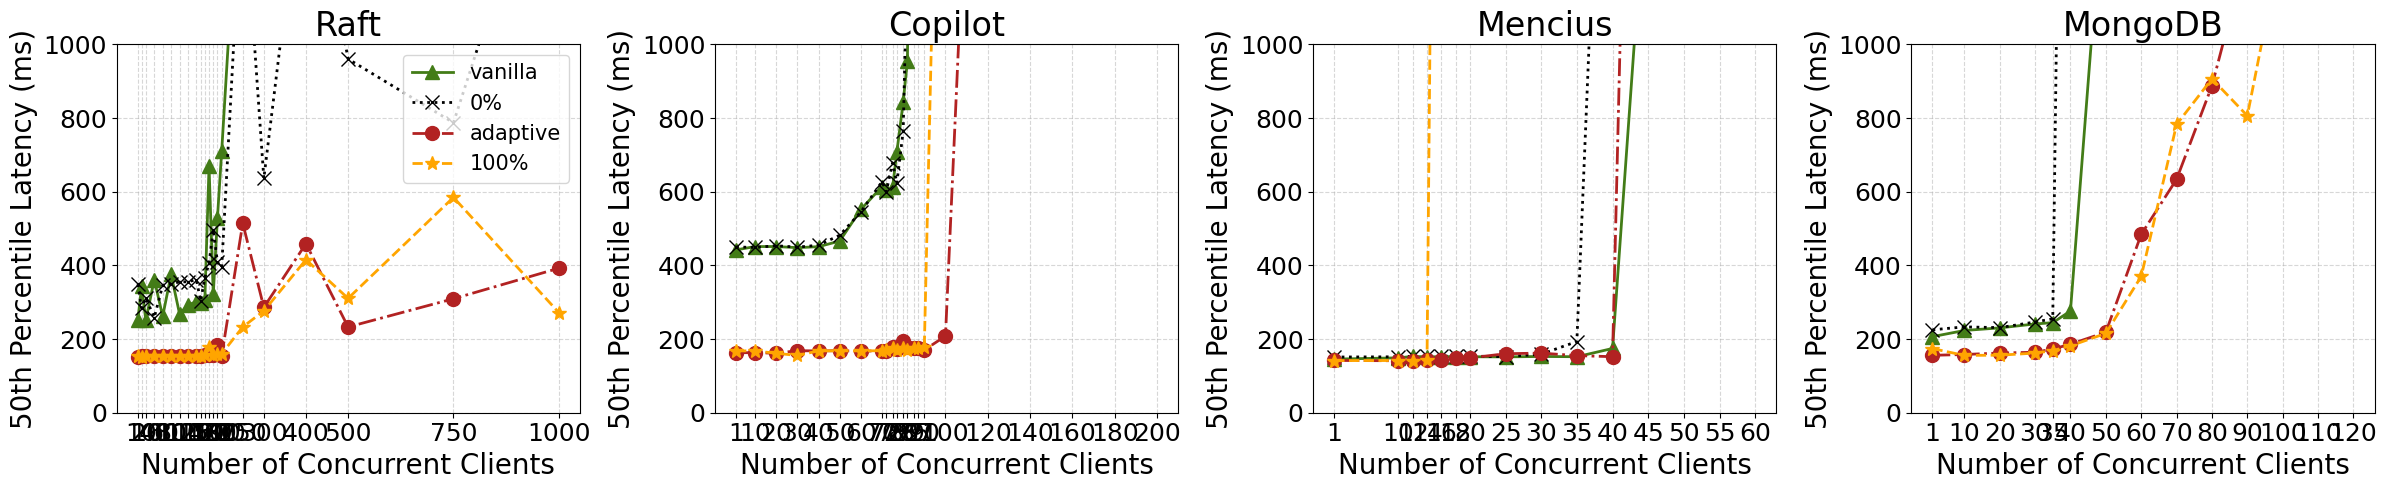

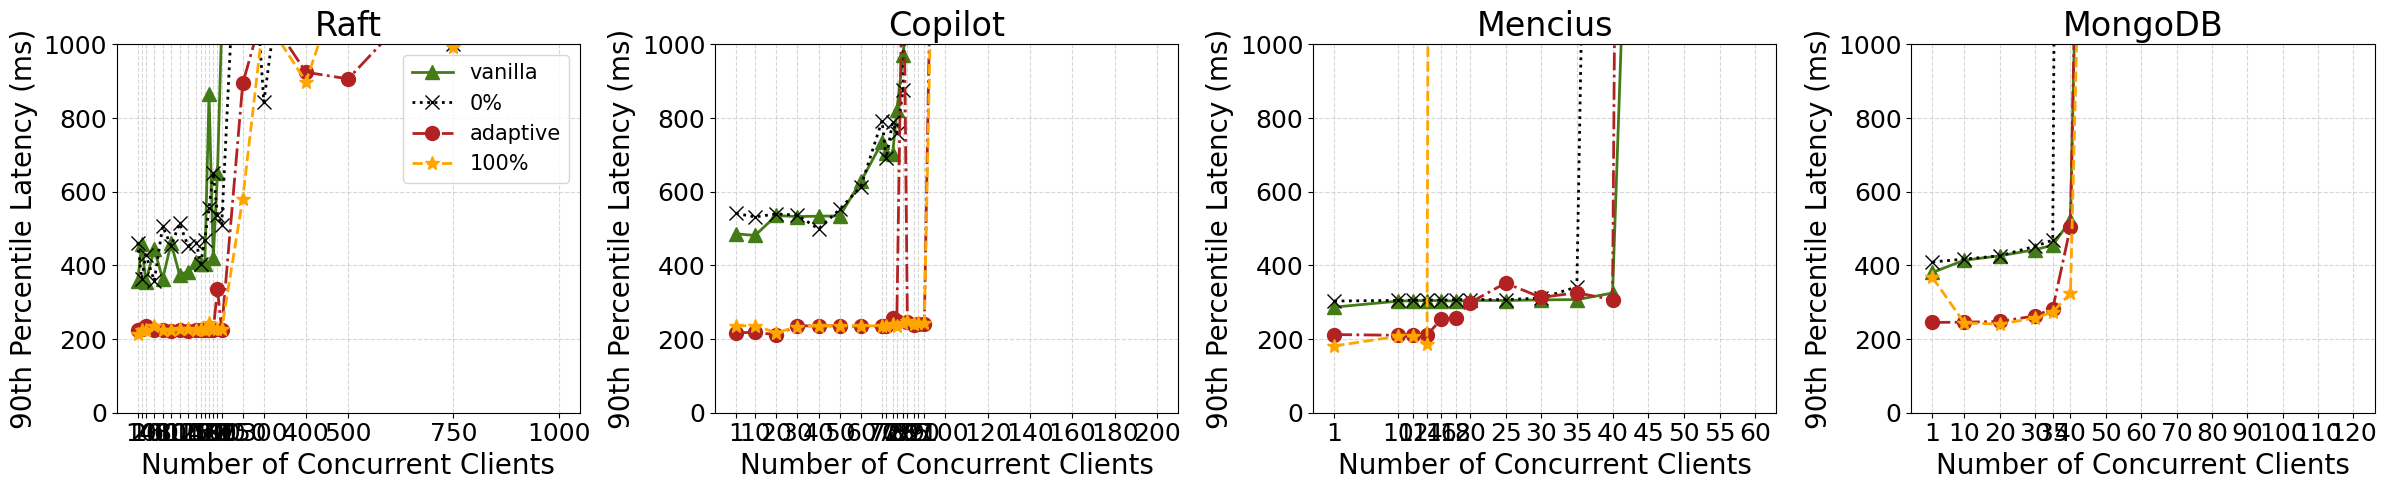

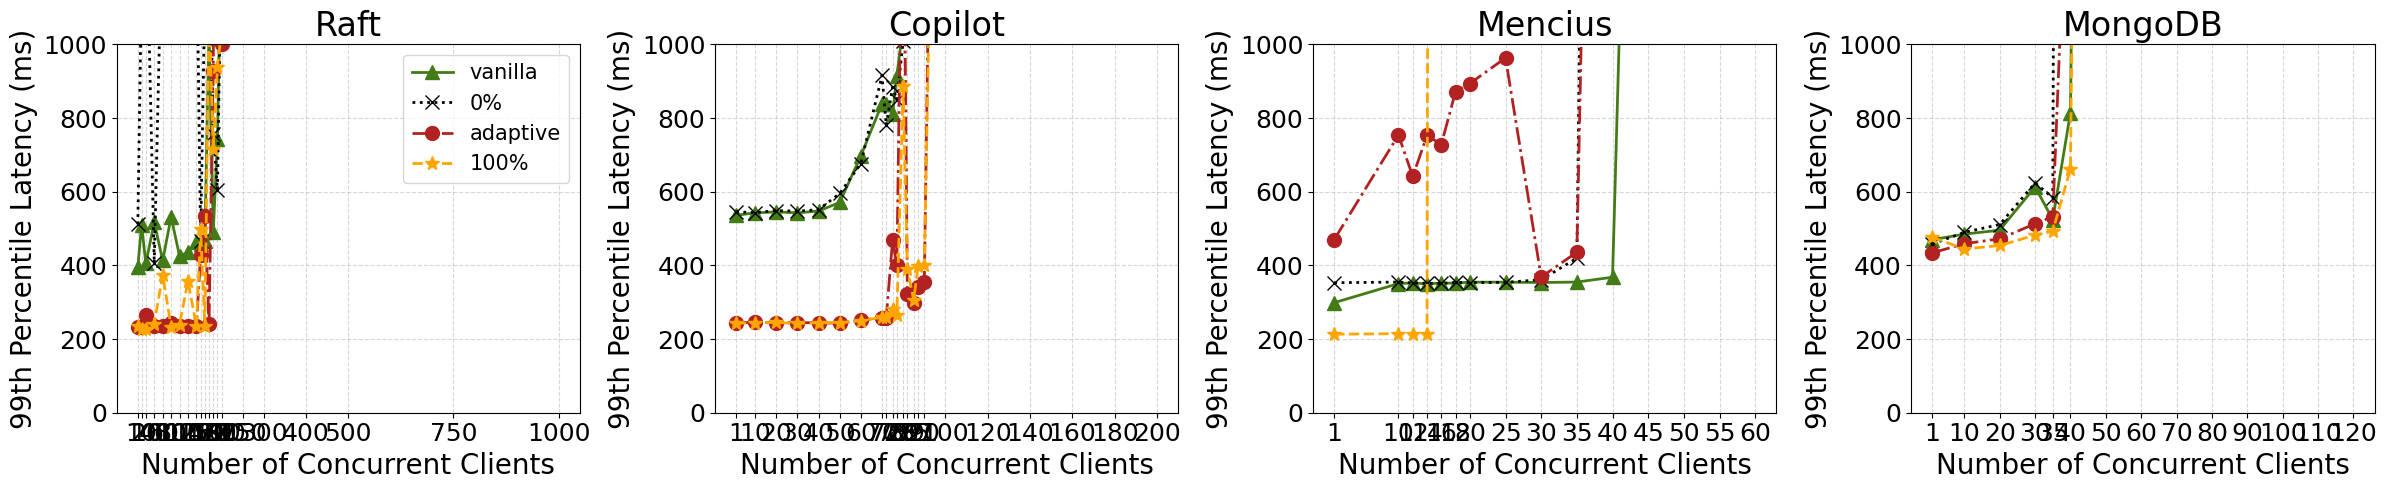

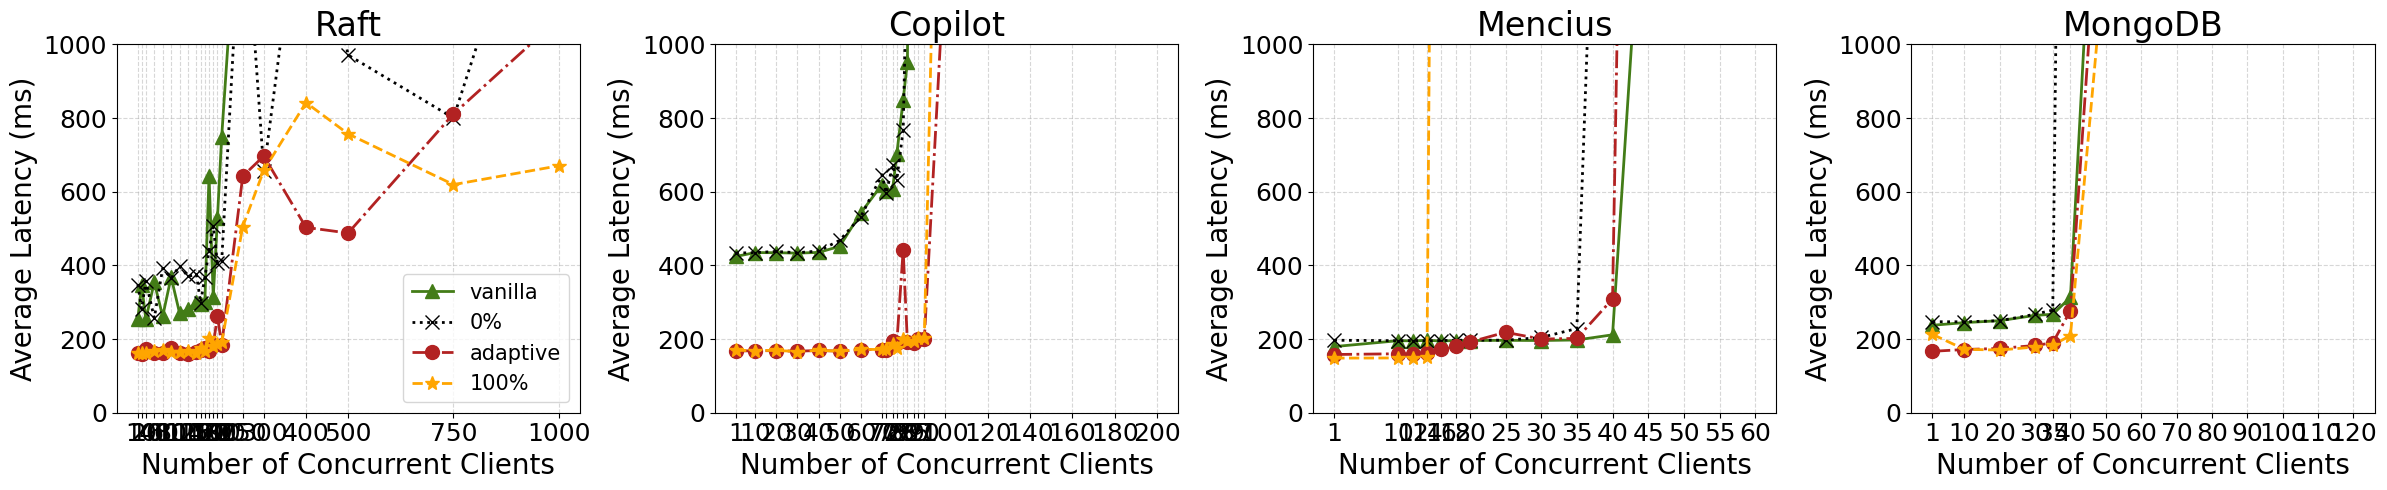

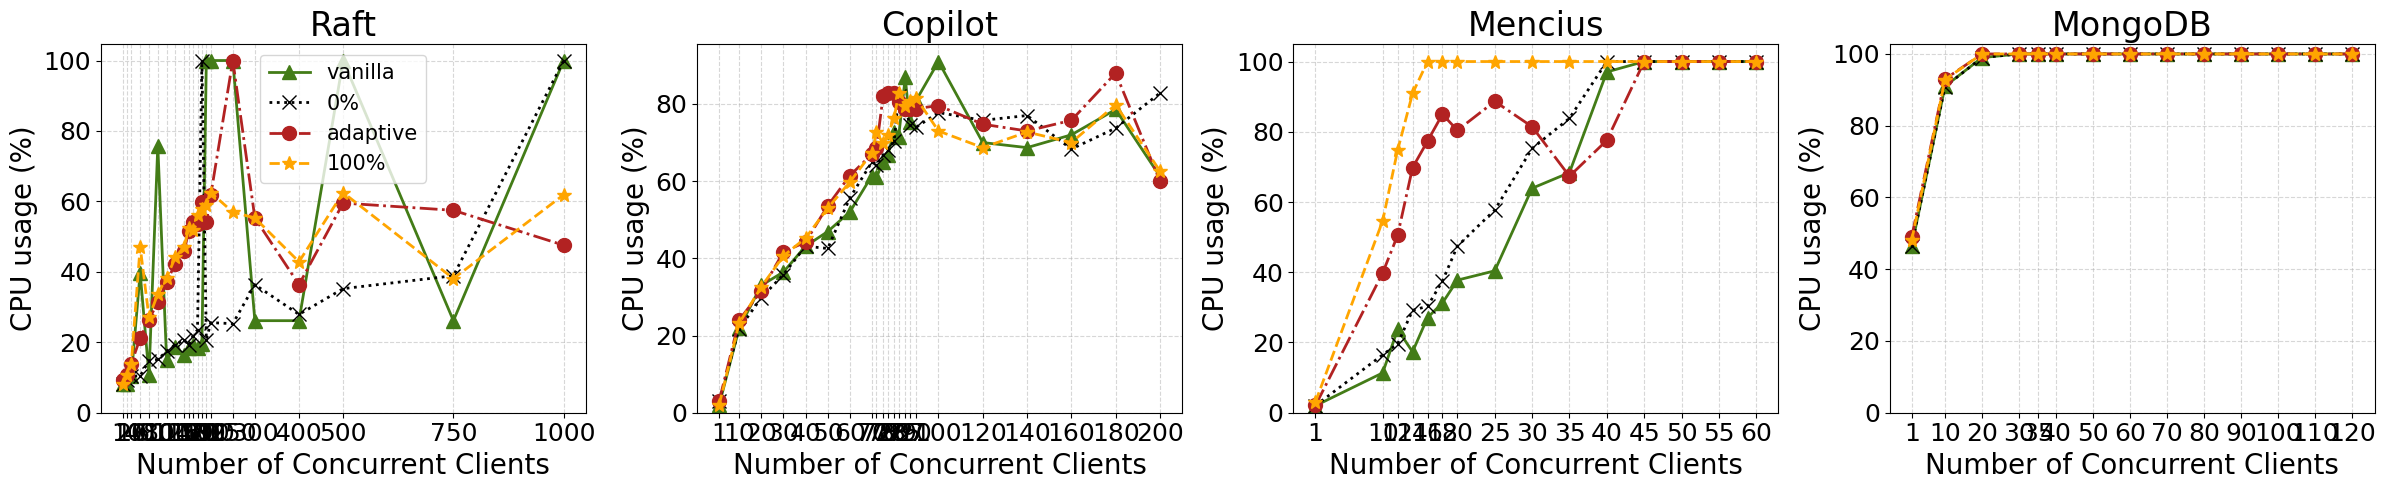

In [8]:
n_proto = len(protocol_name)
def draw_conc_latency(ax, conc, latency_list,
                      ylabel,
                      show_legend=False):
    sorted_rows = sorted(zip(conc, *latency_list), key=lambda row: row[0])
    x = [row[0] for row in sorted_rows]
    ys = list(zip(*[row[1:] for row in sorted_rows]))
    for idx, y in enumerate(ys):
        if idx >= len(configs):
            break
        label, color, marker, linestyle = configs[idx]
        ax.plot(x, y, label=label, color=color,
                marker=marker, linestyle=linestyle, linewidth=line_width, ms=marker_size)
    ax.set_xticks(x)
    ax.set_ylabel(ylabel, fontsize=ylabel_font_size)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylim(bottom=0)
    if "Latency" in ylabel:
        ax.set_ylim(top=1000)
    if show_legend:
        ax.legend(fontsize=legend_font_size)

protocol_titles = protocol_name  # dynamic: 6 protocols for Zoo


def safe_latency_metric(ds, proto, ycsb, wl, rep, cnum, metric, component="all", default=0.0):
    try:
        return ds[proto][ycsb][wl][rep][cnum][metric][component]
    except KeyError as exc:
        proto_slice = ds.get(proto, {})
        ycsb_slice = proto_slice.get(ycsb, {})
        workload_slice = ycsb_slice.get(wl, {})
        replica_slice = workload_slice.get(rep, {})
        available_concs = list(replica_slice.keys()) if isinstance(replica_slice, dict) else []
        metric_slice = replica_slice.get(cnum, {}) if isinstance(replica_slice, dict) else {}
        available_metrics = list(metric_slice.keys()) if isinstance(metric_slice, dict) else []
        print(f"[DEBUG] missing {metric}->{component} for {proto} {ycsb} {wl} rep={rep} conc={cnum}: {exc}. Available concs: {available_concs}, metrics: {available_metrics}")
        return default


def safe_cpu_usage_metric(ds, proto, ycsb, wl, rep, cnum, default=0.0):
    try:
        cpu_map = ds[proto][ycsb][wl][rep][cnum]["cpu_usage"]
    except KeyError as exc:
        proto_slice = ds.get(proto, {})
        ycsb_slice = proto_slice.get(ycsb, {})
        workload_slice = ycsb_slice.get(wl, {})
        replica_slice = workload_slice.get(rep, {})
        available_concs = list(replica_slice.keys()) if isinstance(replica_slice, dict) else []
        print(f"[DEBUG] missing cpu_usage for {proto} {ycsb} {wl} rep={rep} conc={cnum}: {exc}. Available concs: {available_concs}")
        return default

    if isinstance(cpu_map, dict):
        values = []
        for cpu_id, val in cpu_map.items():
            try:
                values.append(float(val))
            except (TypeError, ValueError):
                print(f"[DEBUG] non-numeric cpu_usage[{cpu_id}]={val} for {proto} {wl} rep={rep} conc={cnum}; treating as 0")
        if values:
            return float(values[0])
            return float(np.nanmean(values))
        print(f"[DEBUG] cpu_usage map empty for {proto} {wl} rep={rep} conc={cnum}; using default")
        return default

    try:
        return float(cpu_map)
    except (TypeError, ValueError):
        print(f"[DEBUG] unexpected cpu_usage type {type(cpu_map)} for {proto} {wl} rep={rep} conc={cnum}; using default")
        return default


metrics = [
    ("ae_50",
     lambda ds, proto, ycsb, wl, rep, cnum:
       safe_latency_metric(ds, proto, ycsb, wl, rep, cnum, "ae_50"),
     "50th Percentile Latency (ms)"),
    ("ae_90",
     lambda ds, proto, ycsb, wl, rep, cnum:
       safe_latency_metric(ds, proto, ycsb, wl, rep, cnum, "ae_90"),
     "90th Percentile Latency (ms)"),
    ("ae_99",
     lambda ds, proto, ycsb, wl, rep, cnum:
       safe_latency_metric(ds, proto, ycsb, wl, rep, cnum, "ae_99"),
     "99th Percentile Latency (ms)"),
    ("ae_ave",
     lambda ds, proto, ycsb, wl, rep, cnum:
       safe_latency_metric(ds, proto, ycsb, wl, rep, cnum, "ae_ave"),
     "Average Latency (ms)"),
    ("cpu_usage",
     lambda ds, proto, ycsb, wl, rep, cnum:
       safe_cpu_usage_metric(ds, proto, ycsb, wl, rep, cnum),
     "CPU usage (%)"),
]

for site in sites:

    for row, (key, acc, ylab) in enumerate(metrics):

        fig, axes = plt.subplots(1, n_proto, figsize=(6 * n_proto, 5), sharex='col')
        
        for col, (jetpack, orig) in enumerate(protocols):
            
            axes[col].set_title(protocol_titles[col], fontsize=title_font_size)
        
            ax = axes[col]
            conc = []
            series = [[] for _ in configs]

            for cnum in conc_number[orig]:
                n = int(cnum.rsplit("_", 1)[1])
                conc.append(n)
                # vanilla @ '0'
                series[0].append(acc(data[site], orig,   "YCSB_A", "rw_1000000", '0',  cnum))
                # jetpack @ '0'
                series[1].append(acc(data[site], jetpack, "YCSB_A", "rw_1000000", '0',  cnum))
                # jetpack @ '101'
                series[2].append(acc(data[site], jetpack, "YCSB_A", "rw_1000000", '101',cnum))
                # jetpack @ '100'
                series[3].append(acc(data[site], jetpack, "YCSB_A", "rw_1000000", '100',cnum))

            show_legend = (col == 0)
            draw_conc_latency(ax, conc, series,
                              ylabel=ylab,
                              show_legend=show_legend)

            ax.set_xlabel("Number of Concurrent Clients", fontsize=xlabel_font_size)


        plt.tight_layout()
        fig.savefig(f"{target_folder}/{site_tag}_conc_latency_rw_1000000_YCSB_A_{key}.pdf",
                    bbox_inches="tight")
        plt.show()


[INFO] keep none_raft pct=0 concurrent_1: dispatch(s) 0.00~38.97, throughput=40.60, latency=358.49
[INFO] keep none_raft pct=0 concurrent_10: dispatch(s) 0.00~39.31, throughput=574.20, latency=458.62
[INFO] keep none_raft pct=0 concurrent_20: dispatch(s) 0.00~39.17, throughput=1175.10, latency=356.10
[INFO] keep none_raft pct=0 concurrent_40: dispatch(s) 0.00~39.52, throughput=2365.40, latency=444.18
[INFO] keep none_raft pct=0 concurrent_60: dispatch(s) 0.00~38.88, throughput=3559.40, latency=363.49
[INFO] keep none_raft pct=0 concurrent_80: dispatch(s) 0.00~40.35, throughput=4777.30, latency=460.34
[INFO] keep none_raft pct=0 concurrent_100: dispatch(s) 0.00~40.66, throughput=5943.10, latency=374.34
[INFO] keep none_raft pct=0 concurrent_120: dispatch(s) 0.00~39.58, throughput=6433.10, latency=383.17
[INFO] keep none_raft pct=0 concurrent_140: dispatch(s) 0.00~39.07, throughput=8302.90, latency=408.82
[INFO] keep none_raft pct=0 concurrent_150: dispatch(s) 0.00~39.83, throughput=8965

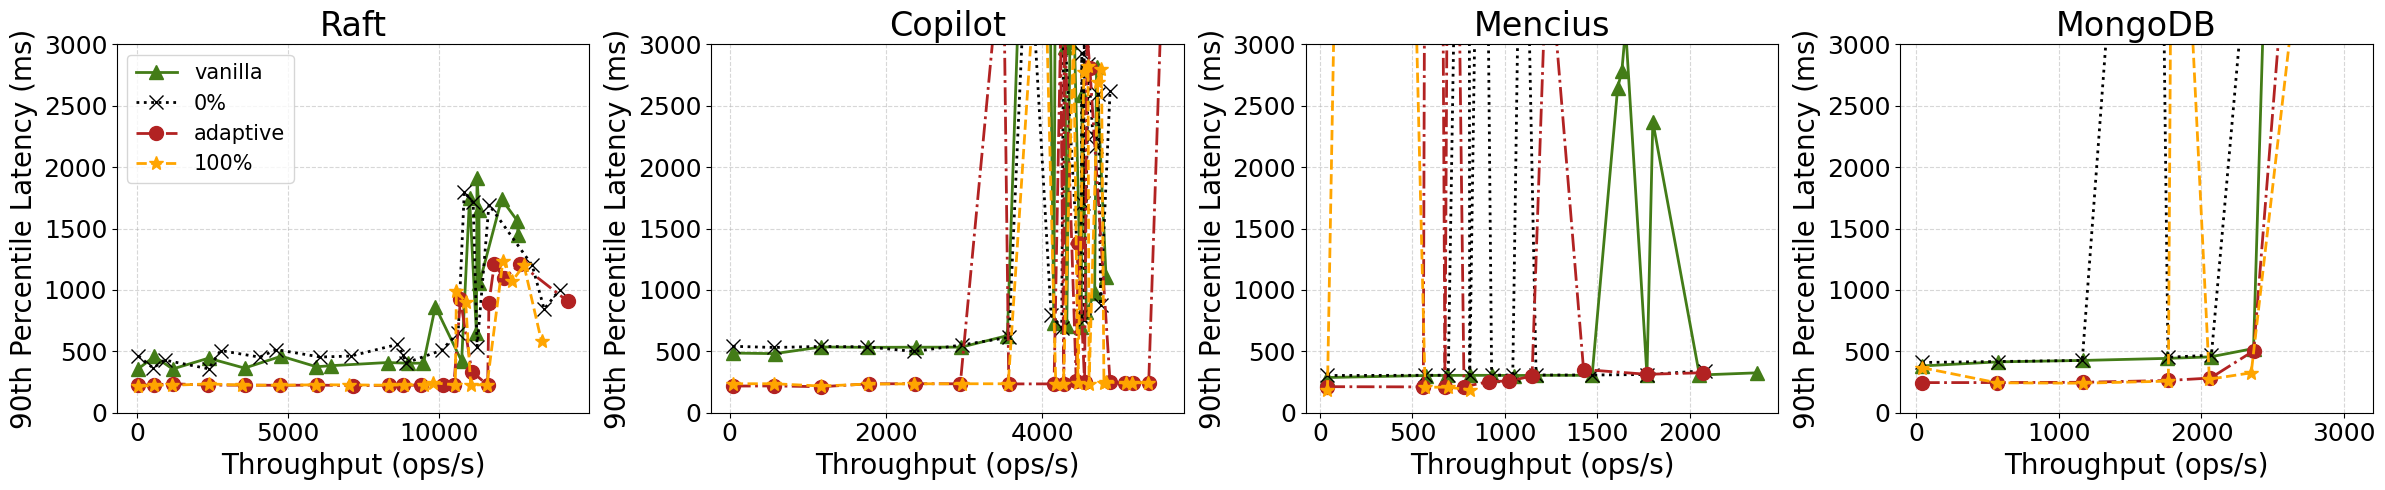

In [9]:
n_proto = len(protocol_name)
def compute_throughput_in_window(dt_list, te_list, window_start=10.0, window_end=20.0, dispatch_max_bounds=(35.0, 45.0)):
    """
    Compute throughput by counting commits finished inside the given window after
    aligning dispatch times to the earliest dispatch. If the dispatch span is not
    within the expected range, return None so the caller can skip that point.
    """
    dt_arrays = []
    te_arrays = []
    for dt_dc, te_dc in zip(dt_list, te_list):
        dt_arr = np.asarray(dt_dc, dtype=float)
        te_arr = np.asarray(te_dc, dtype=float)
        n = min(len(dt_arr), len(te_arr))
        if n == 0:
            continue
        dt_arrays.append(dt_arr[:n])
        te_arrays.append(te_arr[:n])

    if not dt_arrays:
        return None, (0.0, 0.0)

    global_min_dt = min(arr.min() for arr in dt_arrays)
    shifted_dt_arrays = [arr - global_min_dt for arr in dt_arrays]
    all_shifted_dt = np.concatenate(shifted_dt_arrays)

    commit_times_ms = np.concatenate([
        shifted_dt + te_arr
        for shifted_dt, te_arr in zip(shifted_dt_arrays, te_arrays)
    ])
    commit_times_s = commit_times_ms / 1000.0

    dispatch_range_s = (all_shifted_dt.min() / 1000.0, all_shifted_dt.max() / 1000.0)
    max_dispatch_s = dispatch_range_s[1]
    if max_dispatch_s < dispatch_max_bounds[0] or max_dispatch_s > dispatch_max_bounds[1]:
        return None, dispatch_range_s

    window_mask = (commit_times_s >= window_start) & (commit_times_s <= window_end)
    throughput = float(np.count_nonzero(window_mask)) / (window_end - window_start)

    return throughput, dispatch_range_s


def filter_latency_outliers(points, ratio=2.0):
    """
    Remove points whose latency is dramatically higher than the next higher-throughput point.
    Always keeps the highest-throughput point.
    """
    if not points:
        return []
    pts_sorted = sorted(points, key=lambda p: p[4])
    kept = []
    n = len(pts_sorted)
    for i, (thr, lat, dt_range_s, proto_key, pct_key, cnum) in enumerate(pts_sorted):
        if i < n - 1:
            next_lat = pts_sorted[i + 1][1]
            # if next_lat > 0 and lat > next_lat * ratio:
            #     print(f"[WARN] skip latency outlier {proto_key} pct={pct_key} {cnum}: throughput={thr:.2f}, latency={lat:.2f} vs next={next_lat:.2f}")
            #     continue
        kept.append((thr, lat, dt_range_s, proto_key, pct_key, cnum))
    return kept


def draw_throughput_latency(ax, throughputs, latencies, ylabel, show_legend=False):
    for idx, (xs, ys) in enumerate(zip(throughputs, latencies)):
        if idx >= len(configs):
            break
        if not xs:
            continue
        pairs = sorted(zip(xs, ys), key=lambda p: p[0])
        x_vals, y_vals = zip(*pairs)
        label, color, marker, linestyle = configs[idx]
        ax.plot(x_vals, y_vals, label=label, color=color,
                marker=marker, linestyle=linestyle,
                linewidth=line_width, ms=marker_size)
    ax.set_xlabel("Throughput (ops/s)", fontsize=xlabel_font_size)
    ax.set_ylabel(ylabel, fontsize=ylabel_font_size)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylim(bottom=0)
    if "Latency" in ylabel:
        ax.set_ylim(top=3000)
    if show_legend:
        ax.legend(fontsize=legend_font_size)


throughput_latency_metrics = [
    ("ae_ave", "Average Latency (ms)"),
    ("ae_50", "50th Percentile Latency (ms)"),
    ("ae_90", "90th Percentile Latency (ms)"),
    ("ae_99", "99th Percentile Latency (ms)"),
]

THROUGHPUT_WINDOW_DEFAULT = (15.0, 25.0)
# Per-protocol throughput window overrides (substring match on proto_key)
THROUGHPUT_WINDOW_OVERRIDES = {
    "mongodb": (10.0, 20.0),
}
dispatch_bounds_s = (20.0, 60.0)
bad_latency_ratio = 2.0

for site in sites:

    for metric_key, ylab in throughput_latency_metrics:

        fig, axes = plt.subplots(1, n_proto, figsize=(6 * n_proto, 5), sharey=False)

        for col, (jetpack, orig) in enumerate(protocols):

            axes[col].set_title(protocol_titles[col], fontsize=title_font_size)

            throughput_series = [[] for _ in configs]
            latency_series = [[] for _ in configs]
            candidate_points = [[] for _ in configs]

            for cnum in conc_number[orig]:
                combos = [
                    (orig, '0', 0),
                    (jetpack, '0', 1),
                    (jetpack, '101', 2),
                    (jetpack, '100', 3),
                ]
                for proto_key, pct_key, cfg_idx in combos:
                    try:
                        entry = data[site][proto_key]["YCSB_A"]["rw_1000000"][pct_key][cnum]
                    except KeyError as exc:
                        proto_slice = data[site].get(proto_key, {})
                        print(f"[DEBUG] missing data for {proto_key} pct={pct_key} conc={cnum}: {exc}. Available keys: {list(proto_slice.get('YCSB_A', {}).get('rw_1000000', {}).keys())}")
                        continue

                    win = next(
                        (win for key, win in THROUGHPUT_WINDOW_OVERRIDES.items() if key in proto_key),
                        THROUGHPUT_WINDOW_DEFAULT,
                    )
                    thr, dt_range_s = compute_throughput_in_window(
                        entry.get("dt", []),
                        entry.get("te", []),
                        window_start=win[0],
                        window_end=win[1],
                        dispatch_max_bounds=dispatch_bounds_s,
                    )

                    if thr is None:
                        print(f"[WARN] skip {proto_key} pct={pct_key} {cnum}: dispatch(s) {dt_range_s[0]:.2f}~{dt_range_s[1]:.2f} outside {dispatch_bounds_s[0]}~{dispatch_bounds_s[1]}")
                        continue

                    latency_val = safe_latency_metric(
                        data[site],
                        proto_key,
                        "YCSB_A",
                        "rw_1000000",
                        pct_key,
                        cnum,
                        metric_key,
                    )

                    candidate_points[cfg_idx].append((thr, latency_val, dt_range_s, proto_key, pct_key, cnum))

            for cfg_idx, pts in enumerate(candidate_points):
                kept_pts = filter_latency_outliers(pts, ratio=bad_latency_ratio)
                for thr, lat, dt_range_s, proto_key, pct_key, cnum in kept_pts:
                    throughput_series[cfg_idx].append(thr)
                    latency_series[cfg_idx].append(lat)
                    print(f"[INFO] keep {proto_key} pct={pct_key} {cnum}: dispatch(s) {dt_range_s[0]:.2f}~{dt_range_s[1]:.2f}, throughput={thr:.2f}, latency={lat:.2f}")

            draw_throughput_latency(
                axes[col],
                throughput_series,
                latency_series,
                ylabel=ylab,
                show_legend=(col == 0),
            )

        plt.tight_layout()
        fig.savefig(f"{target_folder}/{site_tag}_throughput_latency_rw_1000000_YCSB_A_{metric_key}.pdf", bbox_inches="tight")
        plt.show()


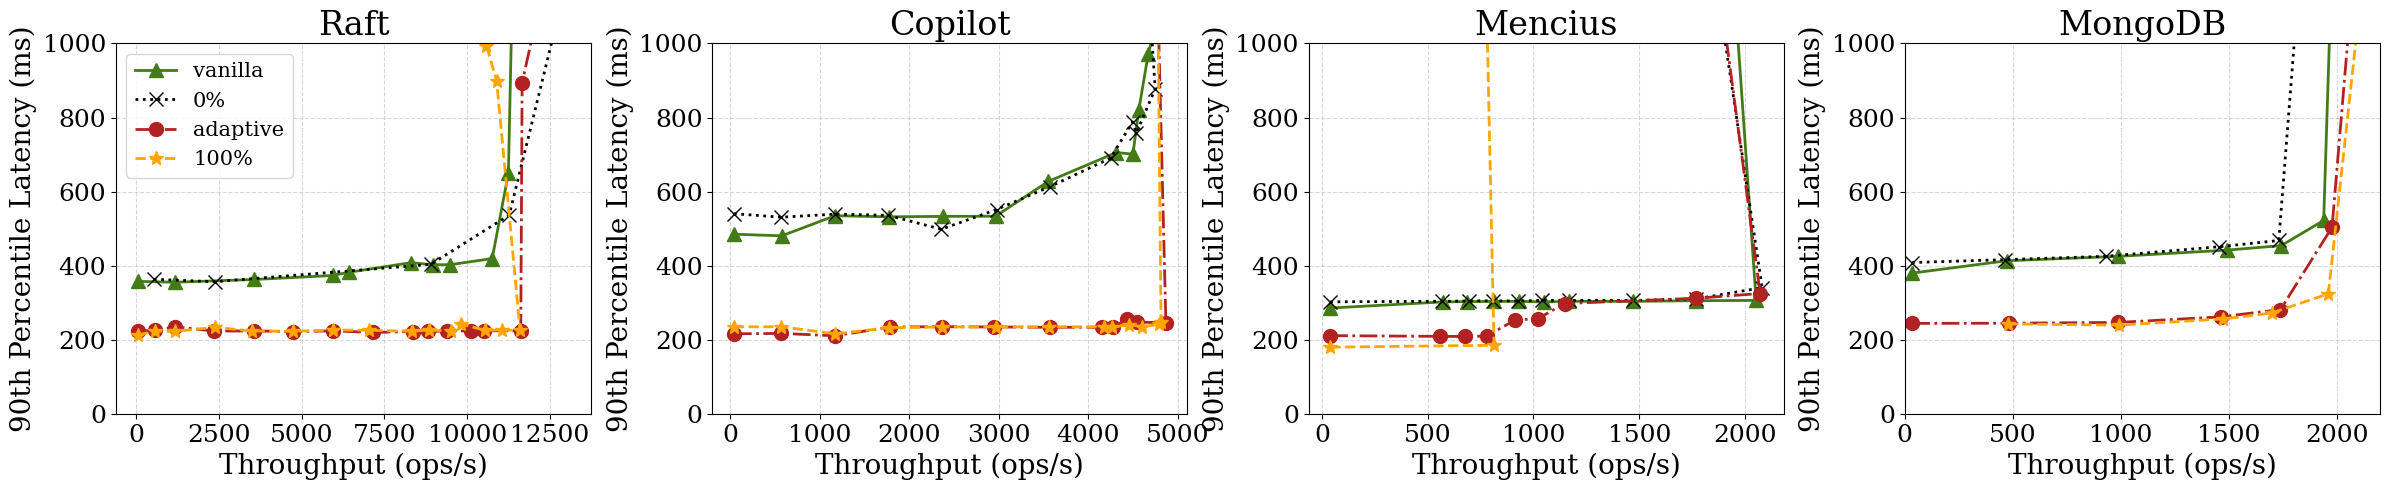

In [45]:
n_proto = len(protocol_name)
def _cnum_to_int(cnum):
    """
    Convert cnum like 'concurrent_120' or '120' to an int 120.
    If it's already an int, return as-is.
    """
    if isinstance(cnum, int):
        return cnum
    if isinstance(cnum, str):
        try:
            return int(cnum.split('_')[-1])
        except ValueError:
            pass
    # Fallback: put weird stuff at the end if ever sorted
    return float('inf')

def filter_latency_outliers(points, ratio=2.0):
    """
    Remove points whose latency is dramatically higher than the minimum latency
    of later (higher-concurrency) points.
    Always keeps the highest-concurrency point.

    points: list of (thr, lat, dt_range_s, proto_key, pct_key, cnum)
            where cnum is already a numeric concurrency.
    """
    if not points:
        return []

    pts_sorted = sorted(points, key=lambda p: p[5])
    kept = []
    n = len(pts_sorted)

    for i, (thr, lat, dt_range_s, proto_key, pct_key, cnum) in enumerate(pts_sorted):
        is_outlier = False

        if i < n - 1:
            later_lats = [p[1] for p in pts_sorted[i + 1:] if p[1] is not None]
            if later_lats:
                min_later = float(min(later_lats))
                if min_later > 0 and lat > min_later * ratio:
                    is_outlier = True

        if is_outlier:
            continue

        kept.append((thr, lat, dt_range_s, proto_key, pct_key, cnum))
        # print(
        #     f"[INFO] keep {proto_key} pct={pct_key} conc={cnum}: "
        #     f"throughput={thr:.2f}, latency={lat:.2f}"
        # )

    return kept


    
def draw_throughput_latency(ax, throughputs, latencies, ylabel, concs=None, show_legend=False):
    for idx, (xs, ys) in enumerate(zip(throughputs, latencies)):
        if idx >= len(configs):
            break
        if not xs:
            continue

        # If concs is provided, connect in increasing conc order.
        if concs is not None:
            cs = concs[idx]
            if not cs:
                continue
            triples = sorted(zip(cs, xs, ys), key=lambda t: t[0])  # sort by conc
            _, x_vals, y_vals = zip(*triples)
        else:
            # Fallback to the old behavior (sort by throughput)
            pairs = sorted(zip(xs, ys), key=lambda p: p[0])
            x_vals, y_vals = zip(*pairs)

        label, color, marker, linestyle = configs[idx]
        ax.plot(x_vals, y_vals, label=label, color=color,
                marker=marker, linestyle=linestyle,
                linewidth=line_width, ms=marker_size)

    ax.set_xlabel("Throughput (ops/s)", fontsize=xlabel_font_size)
    ax.set_ylabel(ylabel, fontsize=ylabel_font_size)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylim(bottom=0)
    if "Latency" in ylabel:
        ax.set_ylim(top=1000)
    if show_legend:
        ax.legend(fontsize=legend_font_size)

throughput_latency_metrics = [
    ("ae_ave", "Average Latency (ms)"),
    ("ae_50", "50th Percentile Latency (ms)"),
    ("ae_90", "90th Percentile Latency (ms)"),
    ("ae_99", "99th Percentile Latency (ms)"),
]

THROUGHPUT_WINDOW_DEFAULT = (15.0, 25.0)
# Per-protocol throughput window overrides (substring match on proto_key)
THROUGHPUT_WINDOW_OVERRIDES = {
    # "mencius": (20.0, 30.0),
    "mongodb": (5.0, 15.0),
}
# Optional throughput x-axis limits (dict keyed by protocol name); leave empty for auto
THROUGHPUT_XLIM_DEFAULT = None
THROUGHPUT_XLIM_OVERRIDES = {
    "none_mongodb": (0, 2200),
}

dispatch_bounds_s = (10.0, 60.0)
bad_latency_ratio = 1.1

# Manual ban list:
# Keys: (proto_key, pct_key) -> iterable of conc numbers to skip.
# Fill this with whatever you want to exclude.
banned_conc = {
    # Examples:
    # ("orig_proto_name", "0"): {256, 384},
    ("none_copilot", "0"): {70},
    ("rule_copilot", "101"): {85, 87, 90, 120},
    ("rule_copilot", "100"): {85, 87, 90},
    ("none_mencius", "0"): {40},
    ("rule_raft", "0"): {160, 170, 200, 300, 750},
    ("rule_raft", "101"): {400, 500},
    ("rule_raft", "100"): {250},
}

for metric_key, ylab in throughput_latency_metrics:

    fig, axes = plt.subplots(1, n_proto, figsize=(6 * n_proto, 5), sharey=False)

    for col, (jetpack, orig) in enumerate(protocols):

        axes[col].set_title(protocol_titles[col], fontsize=title_font_size)

        throughput_series = [[] for _ in configs]
        latency_series = [[] for _ in configs]
        conc_series = [[] for _ in configs]         # track numeric conc
        candidate_points = [[] for _ in configs]

        for cnum_key in conc_number[orig]:
            combos = [
                (orig, '0', 0),
                (jetpack, '0', 1),
                (jetpack, '101', 2),
                (jetpack, '100', 3),
            ]
            
            # numeric concurrency for logic, plotting, bans, etc.
            cnum_val = _cnum_to_int(cnum_key)

            for proto_key, pct_key, cfg_idx in combos:
                # --- manual ban check ---
                banned_set = set(banned_conc.get((proto_key, pct_key), []))
                if cnum_val in banned_set:
                    # print(f"[WARN] manually skip {proto_key} pct={pct_key} conc={cnum_val} (key={cnum_key})")
                    continue
                # -------------------------

                try:
                    # use the ORIGINAL key to index data
                    entry = data[site][proto_key]["YCSB_A"]["rw_1000000"][pct_key][cnum_key]
                except KeyError as exc:
                    proto_slice = data[site].get(proto_key, {})
                    print(
                        f"[DEBUG] missing data for {proto_key} pct={pct_key} conc={cnum_key}: {exc}. "
                        f"Available keys: {list(proto_slice.get('YCSB_A', {}).get('rw_1000000', {}).keys())}"
                    )
                    continue

                win = next(
                    (win for key, win in THROUGHPUT_WINDOW_OVERRIDES.items() if key in proto_key),
                    THROUGHPUT_WINDOW_DEFAULT,
                )
                thr, dt_range_s = compute_throughput_in_window(
                    entry.get("dt", []),
                    entry.get("te", []),
                    window_start=win[0],
                    window_end=win[1],
                    dispatch_max_bounds=dispatch_bounds_s,
                )

                if thr is None:
                    # print(
                    #     f"[WARN] skip {proto_key} pct={pct_key} conc={cnum_val} (key={cnum_key}): "
                    #     f"dispatch(s) {dt_range_s[0]:.2f}~{dt_range_s[1]:.2f} "
                    #     f"outside {dispatch_bounds_s[0]}~{dispatch_bounds_s[1]}"
                    # )
                    continue

                # 🔴 FIX: use cnum_key here, not cnum_val
                latency_val = safe_latency_metric(
                    data[site],
                    proto_key,
                    "YCSB_A",
                    "rw_1000000",
                    pct_key,
                    cnum_key,   # ✅ this matches the dict keys like 'concurrent_1'
                    metric_key,
                )

                # store thr/lat + numeric conc for plotting/filtering
                candidate_points[cfg_idx].append(
                    (thr, latency_val, dt_range_s, proto_key, pct_key, cnum_val)
                )

        for cfg_idx, pts in enumerate(candidate_points):
            kept_pts = filter_latency_outliers(pts, ratio=bad_latency_ratio)
        
            # Re-sort by numeric conc for printing and series insertion
            kept_pts_sorted = sorted(kept_pts, key=lambda p: p[5])  # p[5] = cnum_val
        
            for thr, lat, dt_range_s, proto_key, pct_key, cnum_val in kept_pts_sorted:
                throughput_series[cfg_idx].append(thr)
                latency_series[cfg_idx].append(lat)
                conc_series[cfg_idx].append(cnum_val)
                # print(
                #     f"[INFO] keep {proto_key} pct={pct_key} conc={cnum_val}: "
                #     f"dispatch(s) {dt_range_s[0]:.2f}~{dt_range_s[1]:.2f}, "
                #     f"throughput={thr:.2f}, latency={lat:.2f}"
                # )

        draw_throughput_latency(
            axes[col],
            throughputs=throughput_series,
            latencies=latency_series,
            ylabel=ylab,
            concs=conc_series,   # numeric conc order
            show_legend=(col == 0),
        )

        xlim_override = THROUGHPUT_XLIM_OVERRIDES.get(orig, THROUGHPUT_XLIM_DEFAULT)
        if xlim_override:
            axes[col].set_xlim(xlim_override[0], xlim_override[1])

    plt.tight_layout()
    fig.savefig(f"{target_folder}/{site_tag}_throughput_latency_rw_1000000_YCSB_A_{metric_key}.pdf",
                bbox_inches="tight")
    plt.show()



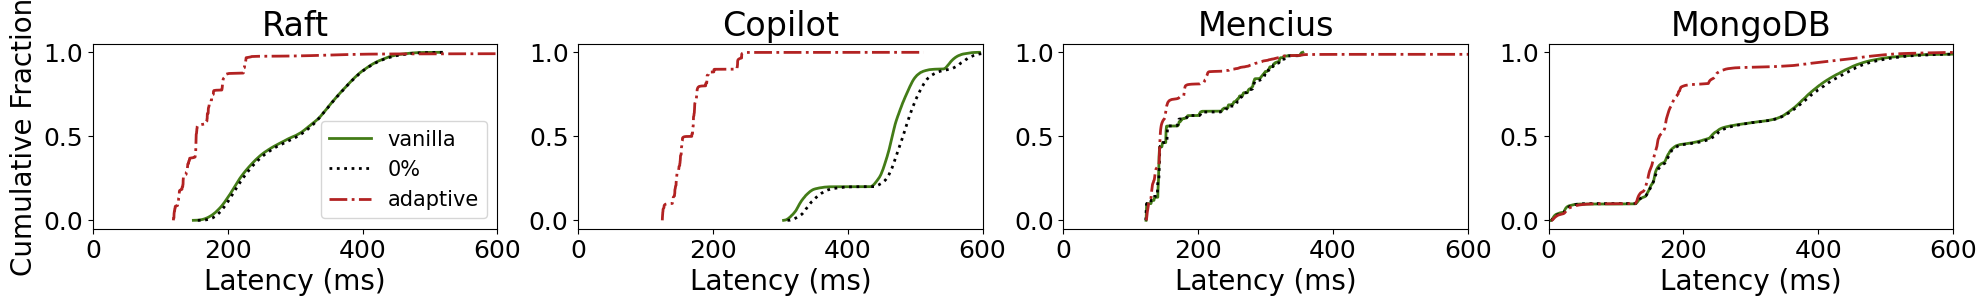

In [14]:
n_proto = len(protocol_name)
from itertools import chain
def draw_latency_line(axes, rule_data, none_data, protocol_name, workload, pcts):
    
    l = [[] for i in range(len(pcts) + 1)]
    y = [[] for i in range(len(pcts) + 1)]
    fixed_conc_override = {"Raft": "concurrent_150"} 
    conc_key = fixed_conc_override.get(protocol_name, fixed_conc_number[protocol_name])
    current_line = list(chain.from_iterable(none_data[workload]['0'][conc_key]['ae']))
    # print(current_line)
    data_length = len(current_line)
    y[0] = [i/data_length for i in range(data_length)]
    l[0] = np.sort(current_line)

    for i, pct in enumerate(pcts):
        conc_key = fixed_conc_override.get(protocol_name, fixed_conc_number[protocol_name])
        try:
            current_line = list(chain.from_iterable(rule_data[workload][pct][conc_key]['ae']))
        except (KeyError, TypeError):
            # Mode data not available yet — use empty list so CDF line is omitted
            current_line = []
            if not current_line:
                continue
        # if pct == "101":
        #     print(current_line)
        data_length = len(current_line)
        y[i + 1] = [i/data_length for i in range(data_length)]
        l[i + 1] = np.sort(current_line)
    # print(l)
    
    for i in range(len(l)):
        if len(l[i]) == 0:
            continue
        axes.plot(l[i], y[i], label = configs[i][0], color = configs[i][1], linestyle=configs[i][3], lw = line_width, ms=marker_size)

    axes.set_xlabel('Latency (ms)', fontsize=xlabel_font_size)
    axes.set_title(protocol_name, fontsize=title_font_size)
    # axes.set_xscale('log')
    if protocol_name == 'MongoDB':
        axes.set_xlim(0, 2200)
    else:
        axes.set_xlim(0, 600)
    return

ticks =[
    ([50,60, 70, 80, 100, 130, 200, 300],[50, 60, 70, 80, 100, 150, 200, 300, 400], [50, 60, 70, 80, 100, 150, 200, 300, 400], [10, 50, 100, 200, 400, 800]),
    ([50,60, 70, 80, 100, 130, 200, 300],[50, 60, 70, 80, 100, 150, 200, 300, 400], [50, 60, 70, 80, 100, 150, 200, 300, 400], [10, 50, 100, 200, 400, 800])
]

latency_data=[
    (data[sites[0]][jp]["YCSB_A"], data[sites[0]][vp]["YCSB_A"], name)
    for (jp, vp), name in zip(protocols, protocol_name)
    if jp in data.get(sites[0], {}) and vp in data.get(sites[0], {})
]
# data["60c1s5r10p"]["rule_raft"]["YCSB_A"]['rw_1000000']['0'][fixed_conc_number["Raft"]]

# for site in sites:
#     for workload_index, workload in enumerate(workloads):
#         fig, axes = plt.subplots(nrows=1, ncols=n_proto, figsize=(6 * n_proto, 4))
    
#         for i, (rule_data, none_data, protocol_name) in enumerate(latency_data):
#             draw_latency_line(axes[i], rule_data, none_data, protocol_name, workload, pcts)
        
#         axes[0].set_ylabel('Cumulative Fraction', fontsize=ylabel_font_size)
#         axes[0].legend(loc='lower right',fontsize=legend_font_size)
#         # for i in range(len(axes)):
#         #     axes[i].set_xticks(ticks[workload_index][i], labels = [str(tick) for tick in ticks[workload_index][i]])
#         fig.savefig(target_folder + "/" + site_tag + "_latency_cumulative_" + workload + ".pdf", bbox_inches="tight")
#         fig.show()
        
for site in sites:
    for workload_index, workload in enumerate(workloads[0:1]):
        fig, axes = plt.subplots(nrows=1, ncols=n_proto, figsize=(24, 2.4))
    
        for i, (rule_data, none_data, protocol_name) in enumerate(latency_data):
            draw_latency_line(axes[i], rule_data, none_data, protocol_name, workload, [p for p in pcts if p != "100"])

        axes[0].set_ylabel('Cumulative Fraction', fontsize=ylabel_font_size)
        axes[0].legend(loc='lower right',fontsize=legend_font_size)
        # for i in range(len(axes)):
        #     axes[i].set_xticks(ticks[workload_index][i], labels = [str(tick) for tick in ticks[workload_index][i]])
        fig.savefig(target_folder + "/" + site_tag + "_latency_cumulative_" + workload + "_print.pdf", bbox_inches="tight")
        fig.show()


# fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
# draw_latency_line(axes, data["60c1s5r10p"]["rule_mencius"]["YCSB_A"], data["60c1s5r10p"]["none_mencius"]["YCSB_A"], 'Mencius', 'rw_1000000', pcts)
# axes.set_ylabel('Cumulative Fraction', fontsize=ylabel_font_size)
# axes.legend(loc='lower right',fontsize=legend_font_size)
# axes.set_xlim(0, 2000)
# fig.savefig(target_folder + "/" + site_tag + "_latency_cumulative_" + 'rw_1000000' + "_mencius_print.pdf", bbox_inches="tight")
# fig.show()


In [ ]:
def get_latency(scope, proto, key_suffix, datacenter_ids):
    return np.mean([
        data[sites[0]][key_suffix][
            "YCSB_A"]["rw_1000000"][scope][fixed_conc_number[key_suffix]]["ae_ave"][dc]
        for dc in datacenter_ids
    ])

def build_key(prefix, proto):
    return f"{prefix}_{proto.lower()}" if proto != "Raft" else f"{prefix}_raft"

n_servers = len(rep_server)  # 5 for Zoo

_completed_protos = []
for proto in num_leader:
    rule_key = build_key("rule", proto)
    none_key = build_key("none", proto)

    # Check if both mode 0 and mode 101 data exist for this protocol
    try:
        _ = data[sites[0]][none_key]["YCSB_A"]["rw_1000000"]["0"]
        _ = data[sites[0]][rule_key]["YCSB_A"]["rw_1000000"]["101"]
    except KeyError:
        print(f"Skipping {proto}: mode 0 or mode 101 data not available yet")
        continue

    leaders = list(range(num_leader[proto]))
    nonleaders = list(range(num_leader[proto], n_servers))

    def fetch(scope, key):  # scope = "0" or "101"
        return data[sites[0]][key]["YCSB_A"]["rw_1000000"][scope][fixed_conc_number[key]]["ae_ave"]

    # All
    vanilla_all = fetch("0", none_key)["all"]
    fast_all = fetch("101", rule_key)["all"]

    # Leaders
    vanilla_leader = get_latency("0", proto, none_key, leaders)
    fast_leader = get_latency("101", proto, rule_key, leaders)

    # Non-leaders
    vanilla_nonleader = get_latency("0", proto, none_key, nonleaders)
    fast_nonleader = get_latency("101", proto, rule_key, nonleaders)

    def pct_improve(old, new):
        return (old - new) / old * 100 if old != 0 else 0

    suffix = proto
    latex_constants.update({
        f"LatencyVanillaAllAve{suffix}": vanilla_all,
        f"LatencyAdaptiveAllAve{suffix}": fast_all,
        f"LatencyAllImprovePct{suffix}": pct_improve(vanilla_all, fast_all),

        f"LatencyVanillaLeaderAve{suffix}": vanilla_leader,
        f"LatencyAdaptiveLeaderAve{suffix}": fast_leader,
        f"LatencyLeaderImprovePct{suffix}": pct_improve(vanilla_leader, fast_leader),

        f"LatencyVanillaNonLeaderAve{suffix}": vanilla_nonleader,
        f"LatencyAdaptiveNonLeaderAve{suffix}": fast_nonleader,
        f"LatencyNonLeaderImprovePct{suffix}": pct_improve(vanilla_nonleader, fast_nonleader),
    })
    _completed_protos.append(proto)


# Build header and rows — only for protocols with data
if _completed_protos:
    header = f"{'Protocol':<10} {'All (ms)':<20} {'All ↓ (%)':<12} {'Leader (ms)':<20} {'Leader ↓ (%)':<15} {'Non-Leader (ms)':<20} {'Non-Leader ↓ (%)':<18}"
    print(header)
    print("-" * len(header))

    for proto in _completed_protos:
        row = [
            proto.ljust(10),
            f"{latex_constants[f'LatencyAdaptiveAllAve{proto}']:.2f} / {latex_constants[f'LatencyVanillaAllAve{proto}']:.2f}".ljust(20),
            f"{latex_constants[f'LatencyAllImprovePct{proto}']:.2f}%".ljust(12),
            f"{latex_constants[f'LatencyAdaptiveLeaderAve{proto}']:.2f} / {latex_constants[f'LatencyVanillaLeaderAve{proto}']:.2f}".ljust(20),
            f"{latex_constants[f'LatencyLeaderImprovePct{proto}']:.2f}%".ljust(15),
            f"{latex_constants[f'LatencyAdaptiveNonLeaderAve{proto}']:.2f} / {latex_constants[f'LatencyVanillaNonLeaderAve{proto}']:.2f}".ljust(20),
            f"{latex_constants[f'LatencyNonLeaderImprovePct{proto}']:.2f}%".ljust(18),
        ]
        print(" ".join(row))
else:
    print("No protocols have both mode 0 and mode 101 data yet")

Protocol   Vanilla (%)     Adaptive (%)    Extra (%)       Overhead (%)   
--------------------------------------------------------------------------
Raft       32.79           56.70           23.91           72.93          
Copilot    25.40           34.52           9.12            35.90          
Mencius    25.87           72.16           46.29           178.94         
MongoDB    80.67           94.57           13.90           17.23          


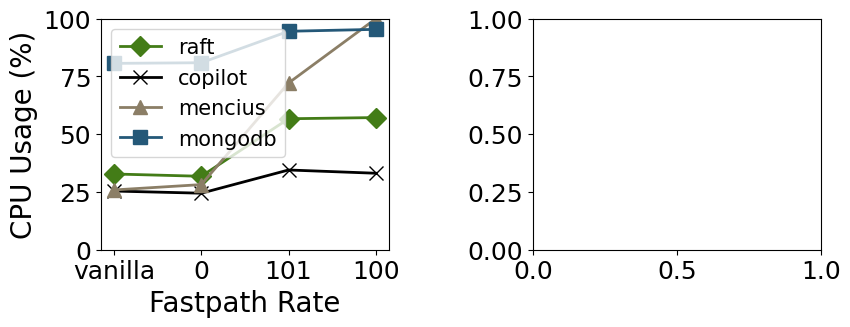

In [19]:
# draw cpu average usage:
# usage - fastpath rate
# raft copilot mencius mongodb
# concurrent 100 -> 5 cpu ->
cpu_line_info = [
    ["raft", '#437c17', "D"],
    ["copilot", "black", "x"],
    ["mencius", "#8b7e66", "^"],
    ["mongodb", "#245878", "s"],
    ["etcd", "#c44e52", "v"],
    ["zookeeper", "#8172b2", "p"],
]
cpus = [i for i in range(5)]
def summarize_cpu_map(cpu_map):
    if not cpu_map:
        return 'missing'
    summary = {}
    for cpu, val in cpu_map.items():
        try:
            summary[cpu] = float(val)
        except (TypeError, ValueError):
            summary[cpu] = val
    return summary

def draw_cpu_usage(axes, data_pct, data_vanilla, title, ylabel_name, workload, protocol_name, l_info):
    # print(data_pct)

    l = [0 for _ in range(len(pcts)+1)]
    conc_key = fixed_conc_number[protocol_name]
    vanilla_cpu_average = 0
    vanilla_cpu_map = data_vanilla.get('0', {}).get(conc_key, {}).get("cpu_usage", {})
    pct_cpu_maps = {pct: data_pct.get(pct, {}).get(conc_key, {}).get("cpu_usage", {}) for pct in pcts}
    # print(f"[DEBUG] {protocol_name} {workload} vanilla cpu_usage: {summarize_cpu_map(vanilla_cpu_map)}")
    # print(f"[DEBUG] {protocol_name} {workload} pct cpu_usage: {{pct: summarize_cpu_map(cpu_map) for pct, cpu_map in pct_cpu_maps.items()}}")
    for cpu in cpus:
        vanilla_cpu_average += vanilla_cpu_map.get(cpu, np.nan)
    l[0] = vanilla_cpu_average / len(cpus)
    
    for i, pct in enumerate(pcts):
        # print(data_pct[pct][fixed_conc_number[protocol_name]]["cpu_usage"])
        # print(cpus)
        cpu_usage = 0
        for cpu in cpus:
            cpu_usage += pct_cpu_maps[pct].get(cpu, np.nan)
            if np.isnan(cpu_usage):
                cpu_usage = np.nan
        l[i + 1] = cpu_usage / len(cpus)

    # print(pcts)
    # print(l)
    if workload == "rw_1000000":
        proto_key = protocol_name if protocol_name != "MongoDB" else "Mongodb"
        prefix = f"CpuUsage"
        latex_constants[f"{prefix}Vanilla{proto_key}"] = l[0]
        latex_constants[f"{prefix}Adaptive{proto_key}"] = l[pcts.index("101")+1]
        latex_constants[f"{prefix}AdaptiveExtra{proto_key}"] = l[pcts.index("101")+1] - l[0]
        latex_constants[f"{prefix}Overhead{proto_key}"] = (l[pcts.index("101")+1] - l[0]) / l[0] * 100

    x = [i for i in range(len(pcts) + 1)]
    axes.plot(["vanilla"] + pcts,l, label=l_info[0], color=l_info[1], marker=l_info[2], lw=line_width, ms=marker_size)


    # axes.set_title(title)
    axes.set_xlabel('Fastpath Rate', fontsize=xlabel_font_size)
    axes.set_ylim(0, 100)
    # axes.set_ylabel(ylabel_name)
    
    axes.legend(loc='upper left',fontsize=legend_font_size)

fig, axes = plt.subplots(nrows=1, ncols=max(1, len(workloads)), figsize=(8 * len(workloads), 3))
if len(workloads) == 1:
    axes = [axes]  # ensure axes is always a list
plt.subplots_adjust(wspace=0.5)
for index, workload in enumerate(workloads):
    for i,(jetpack_data, vanilla_data, protocol_name) in enumerate(protocol_data):
        global legend_draw
        legend_draw = False
    
        draw_cpu_usage(axes[index], jetpack_data[default_ycsb][workload], vanilla_data[default_ycsb][workload], protocol_name + ' ' + workload + ' CPU Usage', 'CPU Usage (%)', workload, protocol_name, cpu_line_info[i])
    
    fig.subplots_adjust(left=0)
axes[0].set_ylabel('CPU Usage (%)', fontsize=ylabel_font_size)
fig.savefig(target_folder + "/" + site_tag + "_cpu_usage_ave.pdf", bbox_inches="tight")
fig.show()

header = f"{'Protocol':<10} {'Vanilla (%)':<15} {'Adaptive (%)':<15} {'Extra (%)':<15} {'Overhead (%)':<15}"
print(header)
print("-" * len(header))

# Rows
for proto in protocol_name:
    key = proto if proto != "MongoDB" else "Mongodb"
    vanilla = latex_constants.get(f"CpuUsageVanilla{key}", float("nan"))
    adaptive = latex_constants.get(f"CpuUsageAdaptive{key}", float("nan"))
    extra = latex_constants.get(f"CpuUsageAdaptiveExtra{key}", float("nan"))
    overhead = latex_constants.get(f"CpuUsageOverhead{key}", float("nan"))

    print(f"{proto:<10} {vanilla:<15.2f} {adaptive:<15.2f} {extra:<15.2f} {overhead:<15.2f}")


[MEM] none_raft conc=1 vanilla=428.74MB jetpack=429.74MB
[MEM] none_raft conc=10 vanilla=457.44MB jetpack=458.09MB
[MEM] none_raft conc=20 vanilla=489.04MB jetpack=501.51MB
[MEM] none_raft conc=40 vanilla=554.20MB jetpack=552.67MB
[MEM] none_raft conc=60 vanilla=616.73MB jetpack=651.66MB
[MEM] none_raft conc=80 vanilla=689.96MB jetpack=731.29MB
[MEM] none_raft conc=100 vanilla=752.49MB jetpack=800.83MB
[MEM] none_raft conc=120 vanilla=777.14MB jetpack=876.58MB
[MEM] none_raft conc=140 vanilla=873.30MB jetpack=950.87MB
[MEM] none_raft conc=150 vanilla=910.24MB jetpack=893.15MB
[MEM] none_raft conc=160 vanilla=933.37MB jetpack=932.99MB
[MEM] none_raft conc=170 vanilla=978.16MB jetpack=1060.05MB
[MEM] none_raft conc=180 vanilla=999.95MB jetpack=984.65MB
[MEM] none_raft conc=190 vanilla=1025.64MB jetpack=1143.15MB
[MEM] none_raft conc=200 vanilla=1046.00MB jetpack=1051.25MB
[MEM] none_raft conc=250 vanilla=1081.16MB jetpack=1399.79MB
[MEM] none_raft conc=300 vanilla=1208.28MB jetpack=1286.

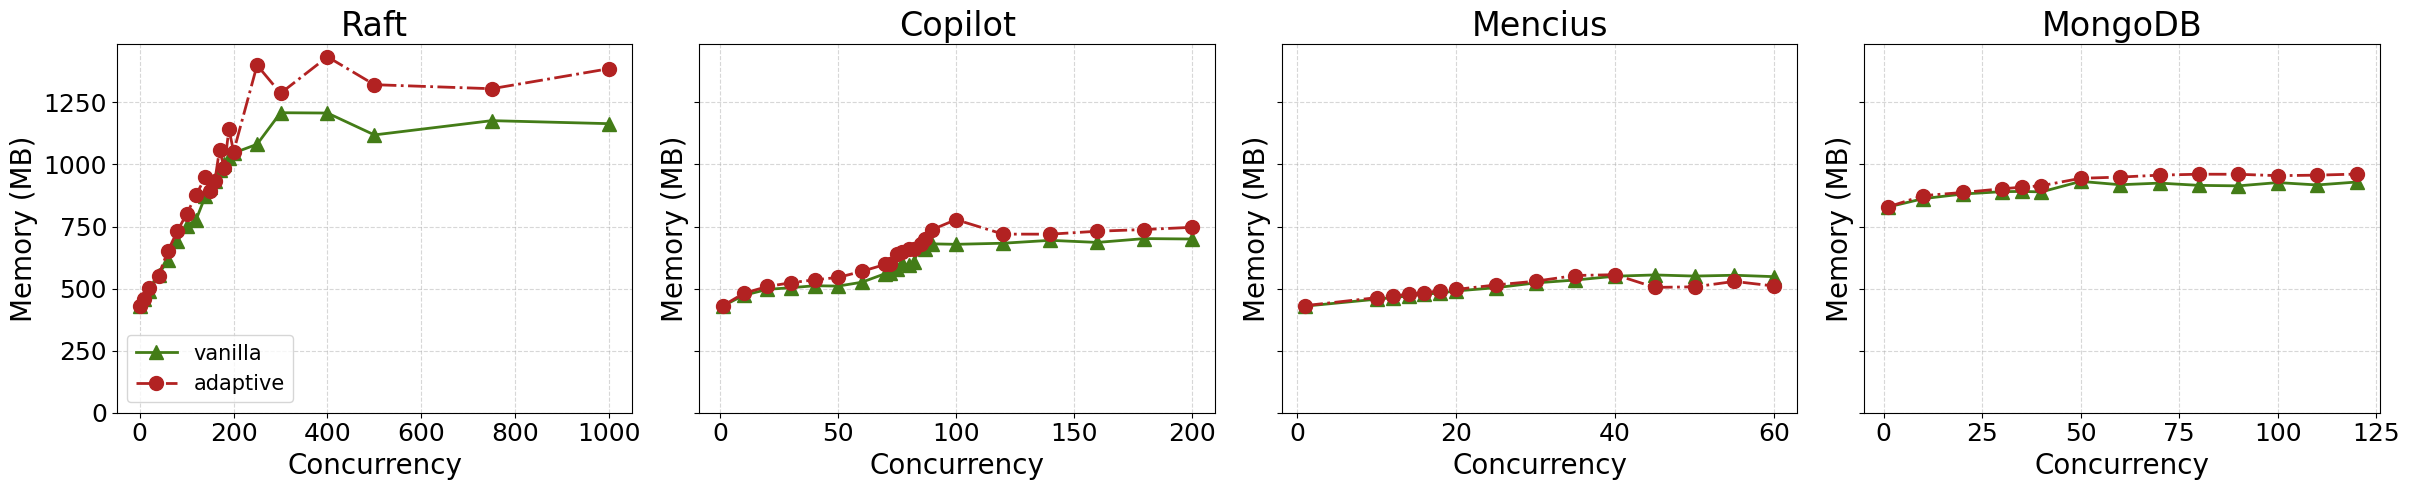

In [20]:
n_proto = len(protocol_name)
# Memory usage vs concurrency (per protocol)
for site in sites:
    fig, axes = plt.subplots(1, n_proto, figsize=(6 * n_proto, 5), sharey=True)
    for col, (jetpack, orig) in enumerate(protocols):
        axes[col].set_title(protocol_titles[col], fontsize=title_font_size)
        x_vals = []
        mem_v = []
        mem_j = []
        for cnum in conc_number[orig]:
            try:
                entry_v = data[site][orig][default_ycsb]["rw_1000000"]["0"][cnum]
                entry_j = data[site][jetpack][default_ycsb]["rw_1000000"]["101"][cnum]
            except KeyError as exc:
                print(f"[WARN] missing memory data for {orig}/{jetpack} conc={cnum}: {exc}")
                continue
            mem_v_val = np.mean(list(entry_v.get("memory_usage", {}).values()) or [0])
            mem_j_val = np.mean(list(entry_j.get("memory_usage", {}).values()) or [0])
            mem_v.append(mem_v_val)
            mem_j.append(mem_j_val)
            x_vals.append(_cnum_to_int(cnum))
            print(f"[MEM] {orig} conc={_cnum_to_int(cnum)} vanilla={mem_v_val:.2f}MB jetpack={mem_j_val:.2f}MB")

        if x_vals:
            v_label, v_color, v_marker, v_ls = configs[0]
            j_label, j_color, j_marker, j_ls = configs[2]
            axes[col].plot(x_vals, mem_v, label=v_label, color=v_color, marker=v_marker, linestyle=v_ls, lw=line_width, ms=marker_size)
            axes[col].plot(x_vals, mem_j, label=j_label, color=j_color, marker=j_marker, linestyle=j_ls, lw=line_width, ms=marker_size)
        axes[col].set_xlabel("Concurrency", fontsize=xlabel_font_size)
        axes[col].set_ylabel("Memory (MB)", fontsize=ylabel_font_size)
        axes[col].grid(True, linestyle='--', alpha=0.5)
        axes[col].set_ylim(bottom=0)
        if col == 0:
            axes[col].legend(fontsize=legend_font_size)
    fig.tight_layout()
    fig.savefig(f"{target_folder}/{site_tag}_memory_usage_conc_{site}.pdf", bbox_inches="tight")
    plt.show()


In [21]:
# latex_constants = {}

_mem_protocols_done = []
for jetpack_data, vanilla_data, protocol in protocol_data[0:]:
    try:
        vanilla = statistics.mean(vanilla_data[default_ycsb]["rw_1000000"]['0'][fixed_conc_number[protocol]]["memory_usage"].values())
        fast = statistics.mean(jetpack_data[default_ycsb]["rw_1000000"]['101'][fixed_conc_number[protocol]]["memory_usage"].values())
    except (KeyError, statistics.StatisticsError):
        # Mode 101 or memory_usage data not available yet
        continue
    overhead = fast - vanilla

    prefix = f"MemoryUsage"
    suffix = f"{protocol if protocol != 'MongoDB' else 'Mongodb'}"
    latex_constants[f"{prefix}Vanilla{suffix}"] = vanilla
    latex_constants[f"{prefix}Adaptive{suffix}"] = fast
    latex_constants[f"{prefix}Overhead{suffix}"] = overhead
    _mem_protocols_done.append(protocol)

if _mem_protocols_done:
    # Header
    header = f"{'Protocol':<10} {'Vanilla (MB)':<15} {'Adaptive (MB)':<15} {'Overhead (MB)':<15}"
    print(header)
    print("-" * len(header))

    # Rows
    for proto in _mem_protocols_done:
        suffix = proto if proto != "MongoDB" else "Mongodb"
        vanilla = latex_constants[f"MemoryUsageVanilla{suffix}"]
        adaptive = latex_constants[f"MemoryUsageAdaptive{suffix}"]
        overhead = latex_constants[f"MemoryUsageOverhead{suffix}"]

        print(f"{proto:<10} {vanilla:<15.2f} {adaptive:<15.2f} {overhead:<15.2f}")
else:
    print("Memory usage comparison skipped — mode 101 data not available yet")

latex_constants


Protocol   Vanilla (MB)    Adaptive (MB)   Overhead (MB)  
----------------------------------------------------------
Raft       873.30          950.87          77.57          
Copilot    510.07          544.94          34.87          
Mencius    477.45          483.17          5.72           
MongoDB    890.31          901.86          11.55          


In [ ]:
# Zipf fast-path rate analysis — requires experiment 1 data
_has_zipf = False
try:
    _test_key = f"rule_{protocol_name[0].lower() if protocol_name[0] != 'Raft' else 'raft'}"
    _ = data[sites[0]][_test_key]["YCSB_A"]["rw_zipf_1"]
    _has_zipf = True
except KeyError:
    print("Skipping zipf rate analysis — experiment 1 data not available yet")

if _has_zipf:
    for proto in protocol_name:
        rule_key = f"rule_{proto.lower() if proto != 'Raft' else 'raft'}"

        for ycsb in ycsb_configs:

            dt = data[sites[0]][rule_key][ycsb]["rw_zipf_1"]["101"][fixed_conc_number[rule_key]]

            reqs = dt["ae_cnt"]["all"]
            attempts = sum(dt["fp_attempt_cnt"].values())
            successes = sum(dt["fp_success_cnt"].values())
            wins = sum(dt["fp_efficient_success_cnt"].values())

            attempt_rate = attempts / reqs * 100 if reqs else 0
            success_rate = successes / attempts * 100 if attempts else 0
            advantage_rate = wins / successes * 100 if successes else 0
            true_benefit_rate = wins / reqs * 100 if reqs else 0

            suffix = "BalancedRW" if ycsb == "YCSB_A" else "ReadHeavyRW"
            
            latex_constants[f"RateAttempt{suffix}{proto}"] = attempt_rate
            latex_constants[f"RateSuccess{suffix}{proto}"] = success_rate
            latex_constants[f"RateAdvantage{suffix}{proto}"] = advantage_rate
            latex_constants[f"RateTrueBenefit{suffix}{proto}"] = true_benefit_rate


    latex_constants


    def build_rate_table(suffix):
        protocols = protocol_name  # dynamic: 6 protocols for Zoo
        rows = []
        for proto in protocols:
            row = {
                "Protocol": proto,
                "Attempt Rate (%)": round(latex_constants[f"RateAttempt{suffix}{proto}"], 2),
                "Success Rate (%)": round(latex_constants[f"RateSuccess{suffix}{proto}"], 2),
                "Advantage Rate (%)": round(latex_constants[f"RateAdvantage{suffix}{proto}"], 2),
                "True Benefit Rate (%)": round(latex_constants[f"RateTrueBenefit{suffix}{proto}"], 2),
            }
            rows.append(row)
        return pd.DataFrame(rows)

    # Display the tables
    print("Metrics for YCSB_A (50% Read / 50% Write)")
    display(build_rate_table("BalancedRW"))

    # print("\nMetrics for YCSB_B (95% Read / 5% Write)")
    # display(build_rate_table("ReadHeavyRW"))

In [ ]:
# Zipf latency plots — requires experiment 1 data
if not _has_zipf:
    print("Skipping zipf latency plots — experiment 1 data not available yet")
else:
    x_ticks = [_.split('_')[-1] for _ in zipf_workloads]
    workload_to_index = {w: i for i, w in enumerate(workloads)}

    latency_metrics = [("ae_ave", "Average Latency(ms)")]  # Add more tuples if needed

    def draw_latency_ycsb(ax, v_data, j_data, latency_type, x_label, protocol_name, pcts):
        l = [[] for _ in range(len(pcts) + 1)]
        conc_key = contention_fixed_conc_number[protocol_name]
        print(f"[DEBUG] draw_latency_ycsb: {protocol_name} expects conc {conc_key}")
        for workload in zipf_workloads:
            try:
                l[0].append(v_data[workload]['0'][conc_key][latency_type]["all"])
            except KeyError as exc:
                vanilla_workload = v_data.get(workload, {})
                available_pcts = list(vanilla_workload.keys())
                available_concs = list(vanilla_workload.get('0', {}).keys()) if '0' in vanilla_workload else []
                print(f"[DEBUG] vanilla missing {exc} for {protocol_name} workload {workload}. Pcts: {available_pcts}, concs: {available_concs}")
                raise
        for i, pct in enumerate(pcts):
            for workload in zipf_workloads:
                try:
                    l[i + 1].append(j_data[workload][pct][conc_key][latency_type]["all"])
                except KeyError as exc:
                    jetpack_workload = j_data.get(workload, {})
                    available_pcts = list(jetpack_workload.keys())
                    available_concs = list(jetpack_workload.get(pct, {}).keys()) if pct in jetpack_workload else []
                    print(f"[DEBUG] jetpack missing {exc} for {protocol_name} workload {workload} pct {pct}. Pcts: {available_pcts}, concs: {available_concs}")
                    raise
        
        tick_positions = list(range(len(x_ticks)))
        tick_labels = x_ticks

        for i in range(len(l)):
            ax.plot(x_ticks, l[i], label=configs[i][0], color=configs[i][1], marker=configs[i][2],
                    linestyle=configs[i][3], lw=line_width, ms=marker_size)
        ax.set_xticks(tick_positions[::2])
        ax.set_xticklabels(tick_labels[::2])
        ax.set_title(protocol_name, fontsize=title_font_size)
        ax.set_ylim(0, 500)

    def plot_latency_metric(latency_type, latency_title, ycsb, suffix="", pcts_override=None):
        fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 9))
        for i, (jetpack_data, vanilla_data, protocol_name) in enumerate(protocol_data):
            draw_latency_ycsb(
                axes[i//2][i%2],
                vanilla_data[ycsb],
                jetpack_data[ycsb],
                latency_type,
                "Zipfian Skew Parameter($\\theta$)",
                protocol_name,
                pcts_override or pcts
            )
        fig.subplots_adjust(left=0.2, wspace=0.2, hspace=0.25)
        axes[0][0].legend(fontsize=legend_font_size, loc="upper left")
        axes[0][0].set_ylabel(latency_title, fontsize=ylabel_font_size)
        axes[1][0].set_ylabel(latency_title, fontsize=ylabel_font_size)
        axes[1][0].set_xlabel("Zipfian Skew Parameter($\\theta$)", fontsize=xlabel_font_size)
        axes[1][1].set_xlabel("Zipfian Skew Parameter($\\theta$)", fontsize=xlabel_font_size)
        filename = f"{target_folder}/{site_tag}_latency_{latency_type}_on_zipf_skew_{ycsb}{suffix}.pdf"
        fig.savefig(filename, bbox_inches='tight')
        fig.show()

    # Run plots for all combinations
    for (latency_type, latency_title) in latency_metrics:
        for ycsb in ycsb_configs[0:1]:
            plot_latency_metric(latency_type, latency_title, ycsb, suffix="_print", pcts_override=[p for p in pcts if p != "100"])


In [ ]:
# Key range latency plots — requires experiment 2 data
_has_key_range = False
try:
    _test_key = f"rule_{protocol_name[0].lower() if protocol_name[0] != 'Raft' else 'raft'}"
    _ = data[sites[0]][_test_key]["YCSB_A"]["rw_1"]
    _has_key_range = True
except KeyError:
    print("Skipping key range latency plots — experiment 2 data not available yet")

if _has_key_range:
    key_range_xticks = [r"$10^0$", r"$10^1$", r"$10^2$", r"$10^3$", r"$10^4$", r"$10^5$", r"$10^6$"]
    key_range_xtick_labels = [r"$10^0$", r"$10^1$", r"$10^2$", r"$10^3$", r"$10^4$", r"$10^5$", r"$10^6$"]

    latency_metrics = [("ae_ave", "Average Latency(ms)")]

    def draw_latency_ycsb(ax, v_data, j_data, latency_type, x_label, protocol_name, pcts):
        l = [[] for _ in range(len(pcts) + 1)]
        for workload in key_range_workloads:
            l[0].append(v_data[workload]['0'][contention_fixed_conc_number[protocol_name]][latency_type]["all"])
        for i, pct in enumerate(pcts):
            for workload in key_range_workloads:
                l[i + 1].append(j_data[workload][pct][contention_fixed_conc_number[protocol_name]][latency_type]["all"])
        
        tick_positions = list(range(len(key_range_xticks)))

        for i in range(len(l)):
            ax.plot(key_range_xticks, l[i], label=configs[i][0], color=configs[i][1], marker=configs[i][2],
                    linestyle=configs[i][3], lw=line_width, ms=marker_size)
        ax.set_xticks(key_range_xticks[::1])
        ax.set_xticklabels(key_range_xtick_labels[::1])
        ax.set_title(protocol_name, fontsize=title_font_size)
        ax.set_ylim(0, 500)

    def plot_latency_metric(latency_type, latency_title, ycsb, suffix="", pcts_override=None):
        fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 9))
        for i, (jetpack_data, vanilla_data, protocol_name) in enumerate(protocol_data):
            draw_latency_ycsb(
                axes[i//2][i%2],
                vanilla_data[ycsb],
                jetpack_data[ycsb],
                latency_type,
                "Key Range (log scale)",
                protocol_name,
                pcts_override or pcts
            )
        fig.subplots_adjust(left=0.2, wspace=0.2, hspace=0.25)
        axes[0][0].legend(fontsize=legend_font_size, loc="lower left")
        axes[0][0].set_ylabel(latency_title, fontsize=ylabel_font_size)
        axes[1][0].set_ylabel(latency_title, fontsize=ylabel_font_size)
        axes[1][0].set_xlabel("Key Range (log scale)", fontsize=xlabel_font_size)
        axes[1][1].set_xlabel("Key Range (log scale)", fontsize=xlabel_font_size)
        filename = f"{target_folder}/{site_tag}_latency_{latency_type}_on_key_range_{ycsb}{suffix}.pdf"
        fig.savefig(filename, bbox_inches='tight')
        fig.show()

    for (latency_type, latency_title) in latency_metrics:
        for ycsb in ycsb_configs[0:1]:
            plot_latency_metric(latency_type, latency_title, ycsb, suffix="_print", pcts_override=[p for p in pcts if p != "100"])


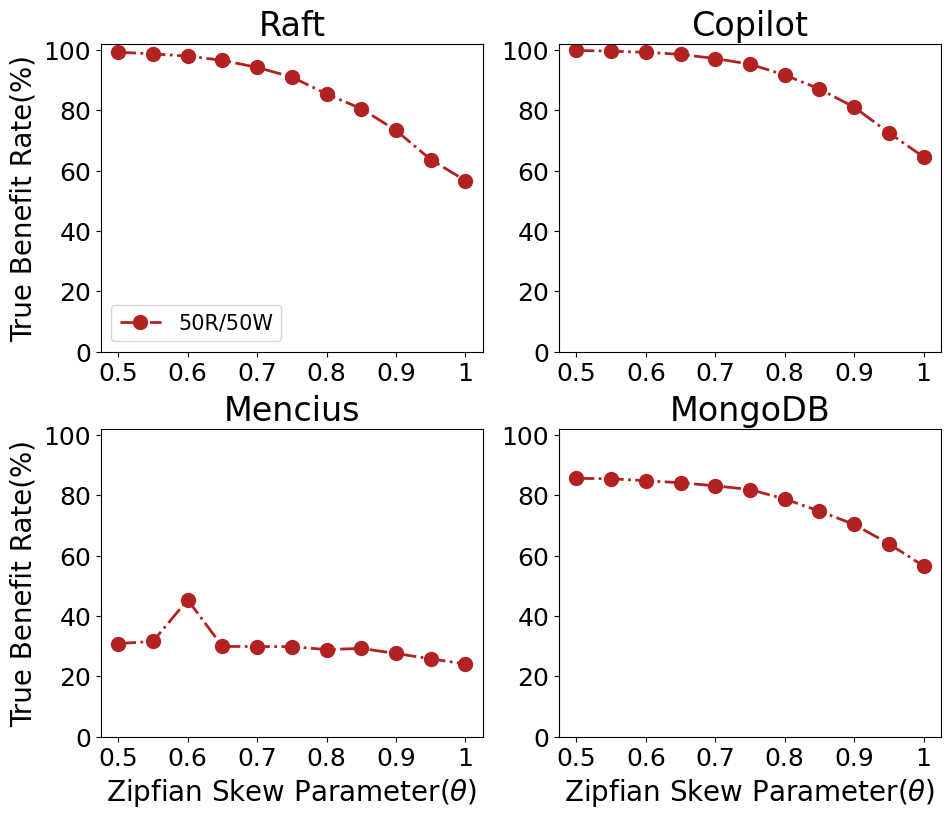

In [346]:
# Guarded: requires data
if not _has_zipf:
    print('Skipping zipf metrics plots — experiment 1 data not available yet')
else:
    n_proto = len(protocol_name)
    x_ticks = [_.split('_')[-1] for _ in zipf_workloads]

    def label_to_prefix(label):
        # Lowercase, replace non-alphanumerics with underscores
        return re.sub(r'[^a-z0-9]+', '_', label.lower()).strip('_')

    def draw_metric_ycsb(ax, j_data, y_label, x_label, protocol_name, compute_fn, ycsb, isprint=False):
        l = [[] for _ in range(len(configs))]

        for i, pct in enumerate(pcts):
            for workload in zipf_workloads:
                dt = j_data[workload][pct][fixed_conc_number[protocol_name]]
                l[i + 1].append(compute_fn(dt))

        for i in range(len(l)):
            if i < 2: continue
            if isprint and i > 2: continue
            ax.plot(x_ticks, l[i], label=configs[i][0], color=configs[i][1], marker=configs[i][2],
                    linestyle=configs[i][3], lw=line_width, ms=marker_size)

        tick_positions = list(range(len(x_ticks)))
        ax.set_xticks(tick_positions[::2])
        ax.set_xticklabels(x_ticks[::2])

        if isprint:
            ax.set_title(protocol_name, fontsize=title_font_size)
        else:
            suffix = "50%R 50%W" if ycsb == "YCSB_A" else "95%R 5%W"
            ax.set_title(f"{protocol_name} {suffix}", fontsize=title_font_size)

        ax.set_xlabel(x_label, fontsize=xlabel_font_size)
        ax.set_ylim(0, 102)


    def plot_metric(y_label, compute_fn, file_prefix=None):
        if file_prefix == None:
            file_prefix = label_to_prefix(y_label)
        for ycsb in ycsb_configs:
            for isprint in [False, True]:
                fig, axes = plt.subplots(nrows=1, ncols=n_proto, figsize=(28, 4))
                for i, (jetpack_data, vanilla_data, protocol_name) in enumerate(protocol_data):
                    draw_metric_ycsb(
                        ax=axes[i],
                        j_data=jetpack_data[ycsb],
                        y_label=y_label,
                        x_label="Zipfian Skew Parameter($\\theta$)",
                        protocol_name=protocol_name,
                        compute_fn=compute_fn,
                        ycsb=ycsb,
                        isprint=isprint
                    )
                fig.subplots_adjust(left=0.2, wspace=0.2)
                axes[0].legend(loc='lower left', fontsize=legend_font_size)
                axes[0].set_ylabel(y_label, fontsize=ylabel_font_size)
                suffix = "_print" if isprint else ""
                filename = f"{target_folder}/{site_tag}_{file_prefix}_on_zipf_skew_{ycsb}{suffix}.pdf"
                fig.savefig(filename, bbox_inches='tight')
                fig.show()

    def plot_merged_print_view(y_label, compute_fn, file_prefix=None):
        if file_prefix is None:
            file_prefix = label_to_prefix(y_label)

        fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 9))

        ycsb_to_label = {
            "YCSB_A": "50R/50W",
            "YCSB_B": "95R/5W"
        }

        for i, (jetpack_data, _, protocol_name) in enumerate(protocol_data):
            for ycsb in reversed(ycsb_configs):
                line_label = ycsb_to_label[ycsb]
                dt_list = []

                for workload in zipf_workloads:
                    # dt = jetpack_data[ycsb][workload][pcts[1]][fixed_conc_number[protocol_name]]  # pcts[1] is "101"
                    try:
                        dt = jetpack_data[ycsb][workload][pcts[1]][fixed_conc_number[protocol_name]]  # pcts[1] is "101"
                    except KeyError as e:
                        print("❌ KeyError encountered!")
                        print(f"Missing key: {e}")
                        print(f"ycsb: {ycsb}")
                        print(f"workload: {workload}")
                        print(f"jetpack_data keys: {list(jetpack_data.keys())}")
                        print(f"jetpack_data[{ycsb}].keys(): {list(jetpack_data.get(ycsb, {}).keys())}")
                        print(f"jetpack_data[{ycsb}][{workload}].keys(): {list(jetpack_data.get(ycsb, {}).get(workload, {}).keys())}")
                        print(jetpack_data.keys())
                        raise e 
                    dt_list.append(compute_fn(dt))
                axes[i//2][i%2].plot(
                    x_ticks, dt_list,
                    label=line_label,
                    color=configs[2][1] if ycsb == "YCSB_A" else configs[3][1],
                    marker=configs[2][2] if ycsb == "YCSB_A" else configs[3][2],
                    linestyle=configs[2][3] if ycsb == "YCSB_A" else configs[3][3],
                    lw=line_width, ms=marker_size
                )

            axes[i//2][i%2].set_title(protocol_name, fontsize=title_font_size)
            tick_positions = list(range(len(x_ticks)))
            axes[i//2][i%2].set_xticks(tick_positions[::2])
            axes[i//2][i%2].set_xticklabels(x_ticks[::2])
            axes[i//2][i%2].set_ylim(0, 102)

        fig.subplots_adjust(left=0.2, wspace=0.2, hspace=0.25)
        axes[0][0].legend(fontsize=legend_font_size, loc="lower left")
        axes[0][0].set_ylabel(y_label, fontsize=ylabel_font_size)
        axes[1][0].set_ylabel(y_label, fontsize=ylabel_font_size)
        axes[1][0].set_xlabel("Zipfian Skew Parameter($\\theta$)", fontsize=xlabel_font_size)
        axes[1][1].set_xlabel("Zipfian Skew Parameter($\\theta$)", fontsize=xlabel_font_size)

        filename = f"{target_folder}/{site_tag}_{file_prefix}_merged_print.pdf"
        fig.savefig(filename, bbox_inches='tight')
        fig.show()

    # # Success rate metric
    # plot_metric(
    #     y_label="Success Rate(%)",
    #     compute_fn=lambda dt: dt["fp_success_rate"],
    # )

    # # Efficient success rate metric
    # plot_metric(
    #     y_label="True Benefit Rate(%)",
    #     compute_fn=lambda dt: sum(dt["fp_efficient_success_cnt"].values()) * 100.0 / dt["ae_cnt"]["all"],
    # )

    plot_merged_print_view(
        y_label="True Benefit Rate(%)",
        compute_fn=lambda dt: sum(dt["fp_efficient_success_cnt"].values()) * 100.0 / dt["ae_cnt"]["all"],
    )


In [22]:
latex_constants_keys = list(latex_constants.keys())
with open(target_folder + "/constants.tex", "w") as file:
    for key in latex_constants_keys:
        # Format the value to 2 decimal places
        formatted_value = f"{latex_constants[key]:.2f}"
        file.write(f"\\newcommand{{\\{key}}}{{{formatted_value}}}\n")
latex_constants

{'LatencyVanillaAllAveRaft': np.float64(299.73469228724434),
 'LatencyAdaptiveAllAveRaft': np.float64(164.97544470353344),
 'LatencyAllImprovePctRaft': np.float64(44.959509543382204),
 'LatencyVanillaLeaderAveRaft': np.float64(367.23860283068086),
 'LatencyAdaptiveLeaderAveRaft': np.float64(176.4757832764818),
 'LatencyLeaderImprovePctRaft': np.float64(51.945198049387045),
 'LatencyVanillaNonLeaderAveRaft': np.float64(292.16412770609384),
 'LatencyAdaptiveNonLeaderAveRaft': np.float64(163.72155420255854),
 'LatencyNonLeaderImprovePctRaft': np.float64(43.9624722281935),
 'LatencyVanillaAllAveCopilot': np.float64(451.6460907132577),
 'LatencyAdaptiveAllAveCopilot': np.float64(167.06305662345116),
 'LatencyAllImprovePctCopilot': np.float64(63.01018428840634),
 'LatencyVanillaLeaderAveCopilot': np.float64(330.3620894005251),
 'LatencyAdaptiveLeaderAveCopilot': np.float64(162.33602857332278),
 'LatencyLeaderImprovePctCopilot': np.float64(50.86118117611568),
 'LatencyVanillaNonLeaderAveCopil

In [40]:
# Copilot Property Data
copilot_property_exps = [
    "copilot-property-none_copilot",
    "copilot-property-rule_copilot-100",
    "copilot-property-rule_copilot-101",
]
copilot_property_data = {}
_copilot_property_available = True
for copilot_property_exp in copilot_property_exps:
    try:
        ae_cnt, ae_50, ae_90, ae_99, ae_ave, \
        throughput, cpu_usage, memory_usage, \
        fp_attempt_cnt, fp_success_cnt, fp_efficient_success_cnt, fp_success_rate, fp_efficient_success_rate, \
        ae, dt, te, failure_time, jetpack_recovery_begin_time, jetpack_recovery_end_time = read_files(copilot_property_exp)

        copilot_property_data[copilot_property_exp] = {
            "ae_cnt": ae_cnt, "ae_50": ae_50, "ae_90": ae_90, "ae_99": ae_99, "ae_ave": ae_ave,
            "throughput": throughput, "cpu_usage": cpu_usage, "memory_usage": memory_usage,
            "fp_attempt_cnt": fp_attempt_cnt, "fp_success_cnt": fp_success_cnt, "fp_efficient_success_cnt": fp_efficient_success_cnt,
            "fp_success_rate": fp_success_rate, "fp_efficient_success_rate": fp_efficient_success_rate,
            "ae": ae, "dt": dt, "te": te,
            "failure_time": failure_time, "jetpack_recovery_begin_time": jetpack_recovery_begin_time, "jetpack_recovery_end_time": jetpack_recovery_end_time
        }
    except Exception as e:
        print(f"Copilot property data not available for {copilot_property_exp}: {e}")
        _copilot_property_available = False

def plot_avg_time_elaps_by_dispatch(datacenter, copilot_property_data, title=None, save_path=None):

    start, end, step = 0, 30, 1  # seconds
    bins = np.arange(start, end, step)
    bin_centers = bins + step / 2

    results = {}

    for exp, data in copilot_property_data.items():
        if exp == "copilot-property-none_copilot":
            line_name = "vanilla"
        elif exp == "copilot-property-rule_copilot-100":
            continue
        elif exp == "copilot-property-rule_copilot-101":
            line_name = "adaptive"
        else:
            raise ValueError(f"Unexpected experiment name: {exp}")

        config_idx = next((i for i, cfg in enumerate(configs) if cfg[0] == line_name), -1)
        if config_idx == -1:
            raise ValueError(f"Config with label '{line_name}' not found.")

        if datacenter == 10:
            dt_all = np.concatenate(data['dt'])
            te_all = np.concatenate(data['te'])
        else:
            dt_all = np.array(data['dt'][datacenter])
            te_all = np.array(data['te'][datacenter])

        averages = []
        for b_start in bins:
            b_end = b_start + step
            mask = (dt_all >= b_start * 1000) & (dt_all < b_end * 1000)
            avg_te = np.mean(te_all[mask]) if np.any(mask) else np.nan
            averages.append(avg_te)

        results[line_name] = (averages, config_idx)

    # Plotting
    plt.figure(figsize=(6, 3))
    for label, (avg_list, config_idx) in results.items():
        plt.plot(
            bin_centers, avg_list,
            label=configs[config_idx][0],
            color=configs[config_idx][1],
            marker=configs[config_idx][2],
            linestyle=configs[config_idx][3],
            lw=line_width,
            ms=marker_size * 0.66
        )

    plt.xlabel("Dispatch Time (s)", fontsize=xlabel_font_size)
    plt.ylabel("Avg. Lat. (ms)", fontsize=ylabel_font_size)
    plt.ylim(0, 700)
    # plt.title(title or f"Average Time Elaps vs Dispatch Time (0s ~ 30s) in datacenter {datacenter}", fontsize=title_font_size)
    # plt.title(title or f"Datacenter {datacenter}", fontsize=title_font_size)
    plt.legend(fontsize=legend_font_size)
    plt.grid(True)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        plt.show()
        plt.close()
    else:
        plt.show()


# for datacenter in range(11):
#     plot_avg_time_elaps_by_dispatch(datacenter, copilot_property_data)

if _copilot_property_available and len(copilot_property_data) >= 2:
    plot_avg_time_elaps_by_dispatch(
        datacenter=3,
        copilot_property_data=copilot_property_data,
        # title="Copilot Slowdown Tolerance Preservation",
        save_path=target_folder + "/" + site_tag + "_copilot_property.pdf"
    )
else:
    print("Copilot property plot skipped — experiment data not available yet")


file_prefix copilot-property-none_copilot


ValueError: not enough values to unpack (expected 21, got 19)

Using cached jetpack_failure_recovery_data
Processing raft-failure-recovery with 10 DCs
dispatch/elapsed lengths per dc: [(20853, 20853), (21474, 21474), (20910, 20910), (20969, 20969), (21013, 21013), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0)]
global dt min (ms) = 1765328197379.093
1765328212789.318 1765328222987.972 1765328222988.101
Downtime: 0.129150390625 ms
total finished ops = 105120
time span(s): 0.149910889 to 75.50729589873437
plot range(s): 0.149910889 to 75.50729589873437
dispatch plot range(s): 0.0 to 75.27465405273438


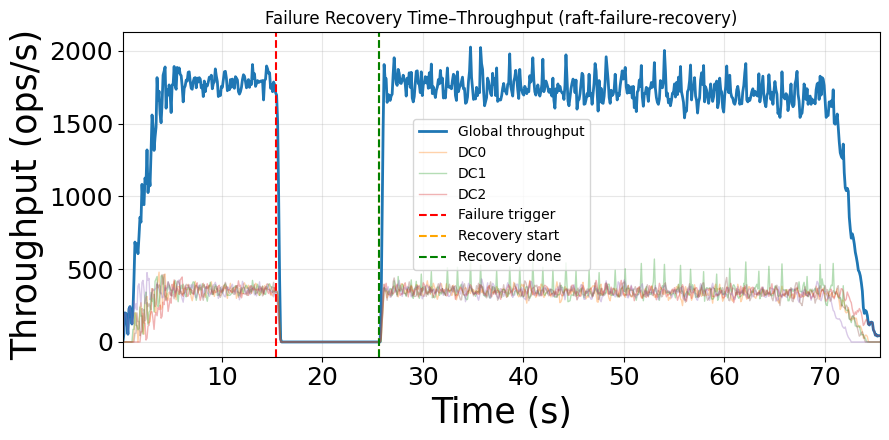

Saved figs/raft-failure-recovery-time-throughput.pdf and figs/raft-failure-recovery-dispatch-throughput.pdf

Processing jetpack-raft-failure-recovery with 10 DCs
dispatch/elapsed lengths per dc: [(21458, 21458), (21458, 21458), (21364, 21364), (21212, 21212), (21160, 21160), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0)]
global dt min (ms) = 1765325090332.364
1765325104847.073 1765325115286.318 1765325116321.844
Downtime: 1035.52587890625 ms
total finished ops = 105982
time span(s): 0.159051025 to 71.7557648930625
plot range(s): 0.159051025 to 71.7557648930625
dispatch plot range(s): 0.0 to 71.39712109375


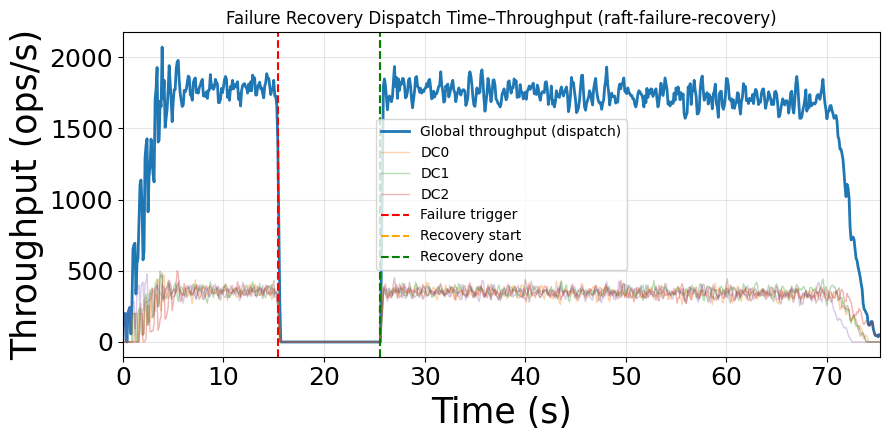

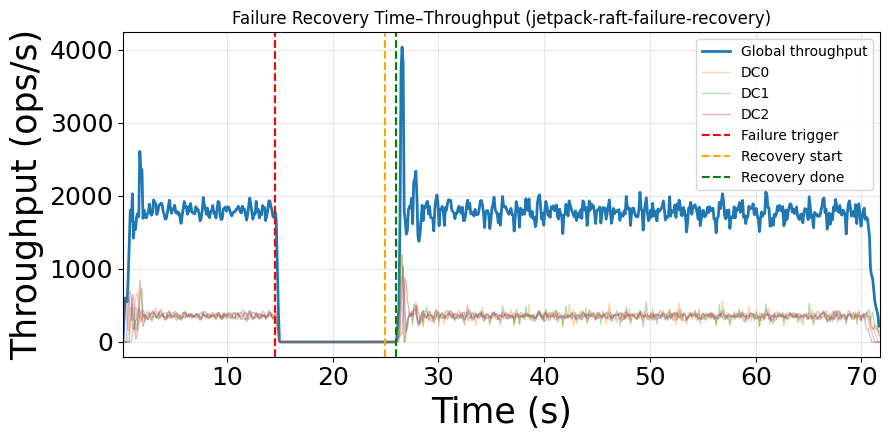

Saved figs/jetpack-raft-failure-recovery-time-throughput.pdf and figs/jetpack-raft-failure-recovery-dispatch-throughput.pdf

Processing mongodb-failure-recovery with 10 DCs
dispatch/elapsed lengths per dc: [(21470, 21470), (21771, 21771), (21603, 21603), (21479, 21479), (21535, 21535), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0)]
global dt min (ms) = 1765321201066.894
1765321216032.46 1765321226513.699 1765321226513.906
Downtime: 0.20703125 ms
total finished ops = 107721
time span(s): 0.0 to 71.41118383789062
plot range(s): 0.0 to 71.41118383789062
dispatch plot range(s): 0.0 to 71.41118383789062


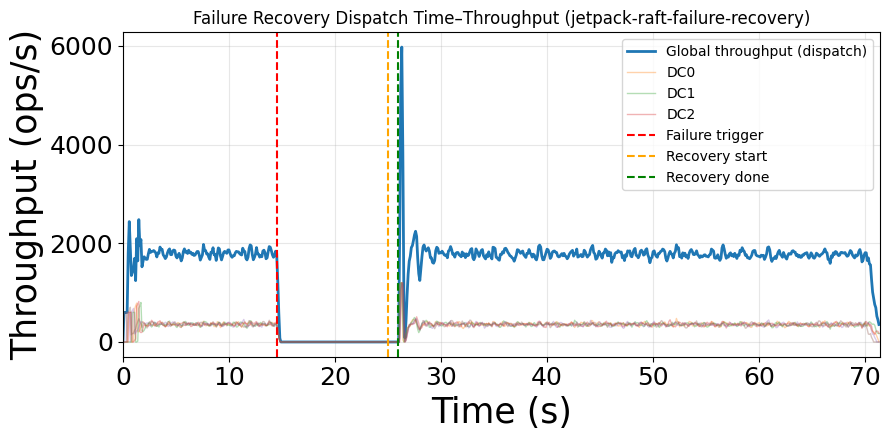

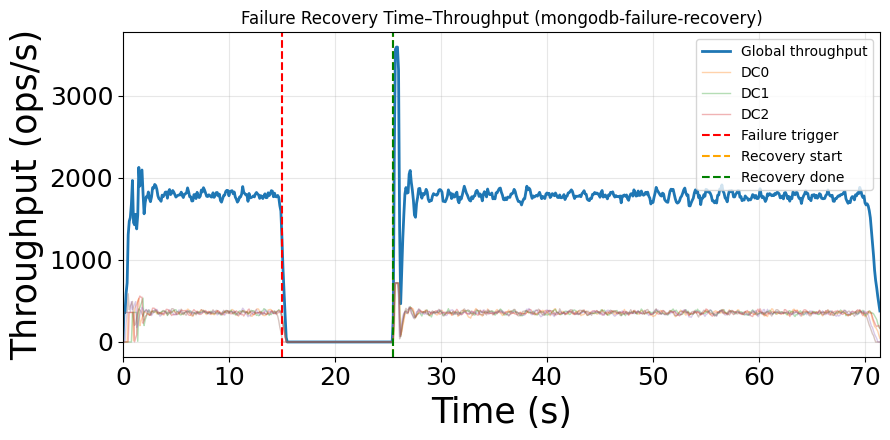

Saved figs/mongodb-failure-recovery-time-throughput.pdf and figs/mongodb-failure-recovery-dispatch-throughput.pdf

Processing jetpack-mongodb-failure-recovery with 10 DCs
dispatch/elapsed lengths per dc: [(18833, 18833), (18881, 18881), (17972, 17972), (18463, 18463), (18206, 18206), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0)]
global dt min (ms) = 1765167631055.366
1765167646084.703 1765167656927.245 1765167658506.811
Downtime: 1579.56591796875 ms
total finished ops = 91808
time span(s): 0.0 to 74.17332006835937
plot range(s): 0.0 to 74.17332006835937
dispatch plot range(s): 0.0 to 74.17332006835937


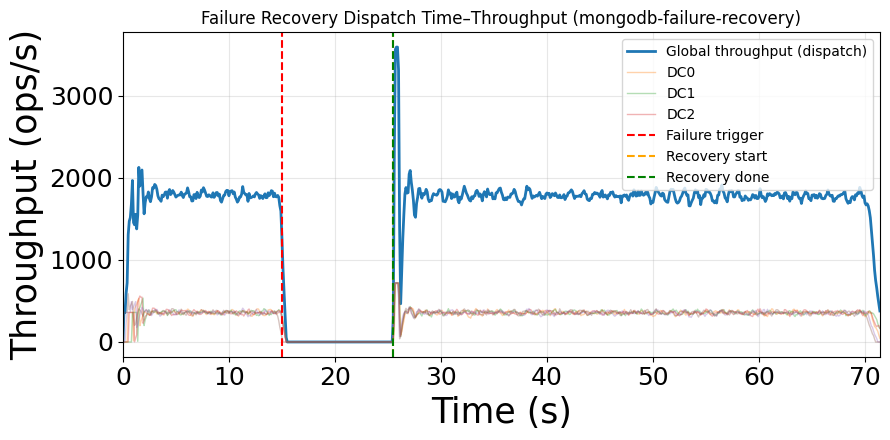

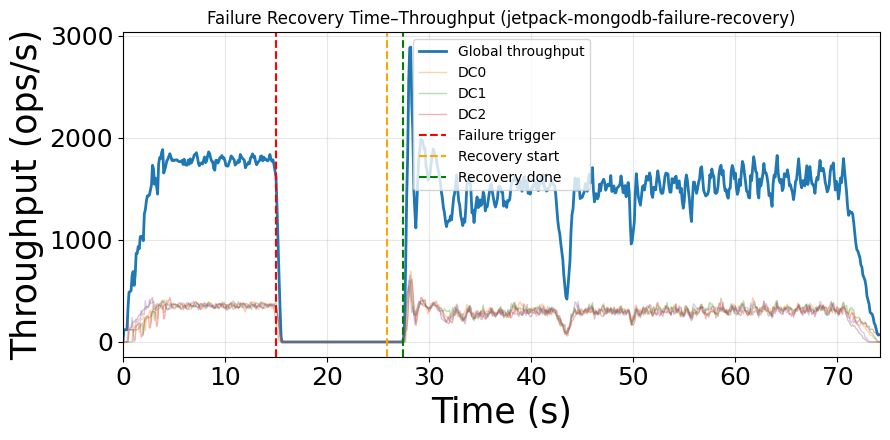

Saved figs/jetpack-mongodb-failure-recovery-time-throughput.pdf and figs/jetpack-mongodb-failure-recovery-dispatch-throughput.pdf



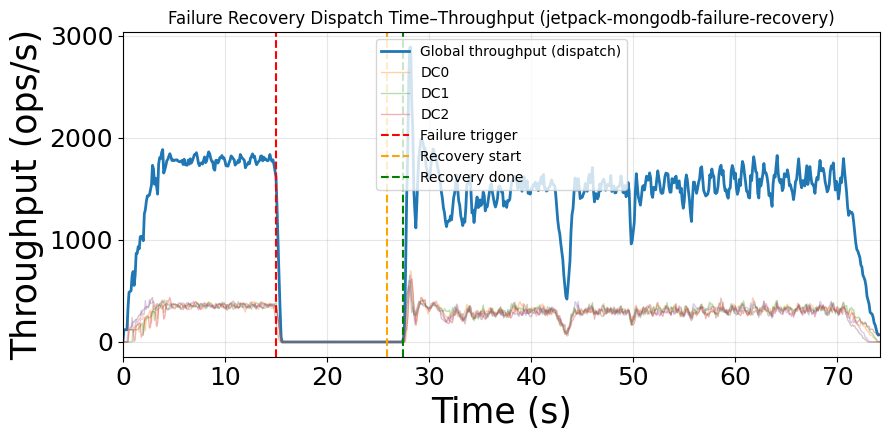

In [692]:
# Jetpack Failure recovery Data

# Cache knobs (rely on globals if already set)
USE_SUMMARY_CACHE = globals().get("USE_SUMMARY_CACHE", False)
SUMMARY_CACHE_PATH = globals().get("SUMMARY_CACHE_PATH", os.path.join(current_dir, "results", exptime + "-summary.pkl"))
SUMMARY_CACHE_VERSION = globals().get("SUMMARY_CACHE_VERSION", 1)
SUMMARY_CACHE_NEEDS_SAVE = globals().get("SUMMARY_CACHE_NEEDS_SAVE", True)

jetpack_failure_recovery_exps = [
    "raft-failure-recovery",
    "jetpack-raft-failure-recovery",
    "mongodb-failure-recovery",
    "jetpack-mongodb-failure-recovery",
]

failure_data_loaded = bool(jetpack_failure_recovery_data)
if not failure_data_loaded:
    jetpack_failure_recovery_data = {}
    for jetpack_failure_recovery_exp in jetpack_failure_recovery_exps:
        ae_cnt, ae_50, ae_90, ae_99, ae_ave,         throughput, cpu_usage, memory_usage,         fp_attempt_cnt, fp_success_cnt, fp_efficient_success_cnt, fp_success_rate, fp_efficient_success_rate,         ae, dt, te, failure_time, jetpack_recovery_begin_time, jetpack_recovery_end_time = read_files(jetpack_failure_recovery_exp)

        jetpack_failure_recovery_data[jetpack_failure_recovery_exp] = {
            "ae_cnt": ae_cnt, "ae_50": ae_50, "ae_90": ae_90, "ae_99": ae_99, "ae_ave": ae_ave,
            "throughput": throughput, "cpu_usage": cpu_usage, "memory_usage": memory_usage,
            "fp_attempt_cnt": fp_attempt_cnt, "fp_success_cnt": fp_success_cnt, "fp_efficient_success_cnt": fp_efficient_success_cnt,
            "fp_success_rate": fp_success_rate, "fp_efficient_success_rate": fp_efficient_success_rate,
            "ae": ae, "dt": dt, "te": te,
            "failure_time": failure_time, "jetpack_recovery_begin_time": jetpack_recovery_begin_time, "jetpack_recovery_end_time": jetpack_recovery_end_time
        }
    SUMMARY_CACHE_NEEDS_SAVE = True
else:
    print("Using cached jetpack_failure_recovery_data")

if USE_SUMMARY_CACHE and SUMMARY_CACHE_NEEDS_SAVE:
    summary_payload = {
        "version": SUMMARY_CACHE_VERSION,
        "exptime": exptime,
        "data": data,
        "rows": rows,
        "this_counter": this_counter,
        "jetpack_failure_recovery_data": jetpack_failure_recovery_data,
    }
    try:
        with open(SUMMARY_CACHE_PATH, 'wb') as f:
            pickle.dump(summary_payload, f)
        SUMMARY_CACHE_NEEDS_SAVE = False
        print(f"Saved summary cache to {SUMMARY_CACHE_PATH}")
    except Exception as exc:
        print(f"Failed to save summary cache: {exc}")

# Choose which DCs to plot, e.g. [0, 1, 2, 3, 4, 5]
DEFAULT_SELECTED_DCS = [0, 1, 2, 3, 4]   # or None for all
# DEFAULT_SELECTED_DCS = None

# Whether to draw the global summed throughput
PLOT_GLOBAL = True

# Default: filter out ops dispatched during recovery window (failure -> recovery end)
DEFAULT_FILTER_RECOVERY_WINDOW = True

### NEW: choose x-range in seconds (relative time)
# Set to None to use data min/max automatically
X_BEGIN = 0.0    # e.g. start at 0s
X_END   = 80.0   # e.g. end at 60s
###

WINDOW_S_DEFAULT = 0.3
STEP_S   = 0.1

# Optional per-experiment overrides (e.g., mongodb tweaks filter/window/latency handling)
FAILURE_RECOVERY_OVERRIDES = {
    "mongodb-failure-recovery": {
        "filter_recovery_window": True,
        "window_s": 0.5,
        "include_latency": False,  # use dispatch times instead of completion times
    },
    "jetpack-mongodb-failure-recovery": {
        "filter_recovery_window": True,
        "window_s": 0.5,
        "include_latency": False,
    },
}

os.makedirs("figs", exist_ok=True)

def make_time_grid(finish_times_s, step_s=0.1, t0=None, t1=None):
    ft = np.asarray(finish_times_s, dtype=float)
    if t0 is None:
        t0 = ft.min()
    if t1 is None:
        t1 = ft.max()
    # add a tiny epsilon to be safe against floating drift
    ts = np.arange(t0, t1 + 1e-9, step_s)
    return ts

def throughput_on_grid(finish_times_s, ts, window_s=1.0):
    """
    finish_times_s: 1D array of finish times (seconds)
    ts: fixed time grid (seconds)
    window_s: sliding window length (seconds)
    Returns throughput ops/s at each ts (same length as ts).
    """
    ft = np.sort(np.asarray(finish_times_s, dtype=float))
    ts = np.asarray(ts, dtype=float)

    # window is (t-window, t]
    left_idx  = np.searchsorted(ft, ts - window_s, side="right")
    right_idx = np.searchsorted(ft, ts,           side="right")
    counts = right_idx - left_idx

    return counts / window_s

for exp in jetpack_failure_recovery_exps:
    data = jetpack_failure_recovery_data[exp]
    dt_all = data["dt"]   # list of length 10, each is list of dispatch times
    te_all = data["te"]   # list of length 10, each is list of elapsed times

    num_dcs = len(dt_all)
    print(f"Processing {exp} with {num_dcs} DCs")

    settings = FAILURE_RECOVERY_OVERRIDES.get(exp, {})
    selected_dcs_cfg = settings.get("selected_dcs", DEFAULT_SELECTED_DCS)
    filter_recovery_window = settings.get("filter_recovery_window", DEFAULT_FILTER_RECOVERY_WINDOW)
    window_s = settings.get("window_s", WINDOW_S_DEFAULT)
    include_latency = settings.get("include_latency", True)
    step_s = settings.get("step_s", STEP_S)

    dt_lengths = [(len(dt_all[i]), len(te_all[i])) for i in range(num_dcs)]
    print("dispatch/elapsed lengths per dc:", dt_lengths)

    # --- compute global minimum dt (ms) and shift everything to be relative ---
    all_dt_arrays = [
        np.asarray(dt_all[i], dtype=float)
        for i in range(num_dcs)
        if len(dt_all[i]) > 0
    ]
    if not all_dt_arrays:
        print(f"No dispatch data for {exp}, skipping.")
        continue

    global_dt_min_ms = min(arr.min() for arr in all_dt_arrays)
    print("global dt min (ms) =", global_dt_min_ms)
    failure_time_ms = data.get("failure_time")
    jetpack_recovery_begin_time_ms = data.get("jetpack_recovery_begin_time")
    jetpack_recovery_end_time_ms = data.get("jetpack_recovery_end_time")

    def to_relative_seconds(ms_val):
        if ms_val is None:
            return None
        return (ms_val - global_dt_min_ms) / 1000.0

    failure_time_s = to_relative_seconds(failure_time_ms)
    jetpack_recovery_begin_time_s = to_relative_seconds(jetpack_recovery_begin_time_ms)
    jetpack_recovery_end_time_s = to_relative_seconds(jetpack_recovery_end_time_ms)

    print(failure_time_ms, jetpack_recovery_begin_time_ms, jetpack_recovery_end_time_ms)
    if jetpack_recovery_begin_time_ms is not None and jetpack_recovery_end_time_ms is not None:
        print("Downtime:", jetpack_recovery_end_time_ms - jetpack_recovery_begin_time_ms, "ms")

    # --- compute finish times (ms) then convert to seconds ---
    finish_times_by_dc = []
    dispatch_times_by_dc = []

    for i in range(num_dcs):
        dt_i = np.asarray(dt_all[i], dtype=float)
        te_i = np.asarray(te_all[i], dtype=float)

        # safety: align length
        n = min(len(dt_i), len(te_i))
        dt_i = dt_i[:n]
        te_i = te_i[:n]

        # shift dispatch times so earliest one is 0
        dt_i = dt_i - global_dt_min_ms    # <<< relative ms now
        if filter_recovery_window and failure_time_s is not None and jetpack_recovery_end_time_s is not None:
            dt_i_s = dt_i / 1000.0
            keep_mask = (dt_i_s < failure_time_s) | (dt_i_s > jetpack_recovery_end_time_s)
            dt_i = dt_i[keep_mask]
            te_i = te_i[:n][keep_mask]

        dt_i_s = dt_i / 1000.0
        dispatch_times_by_dc.append(dt_i_s)

        
        ft_i_ms = dt_i + te_i if include_latency else dt_i      # finish/response time in ms
        ft_i_s  = ft_i_ms / 1000.0    # convert to seconds

        finish_times_by_dc.append(ft_i_s)

    dispatch_times_global = np.concatenate(dispatch_times_by_dc)
    dispatch_times_global.sort()

    # global flatten (all DCs)
    finish_times_global = np.concatenate(finish_times_by_dc)
    finish_times_global.sort()

    print("total finished ops =", len(finish_times_global))
    print("time span(s):", finish_times_global[0], "to", finish_times_global[-1])

    dt_min = dispatch_times_global.min()
    dt_max = dispatch_times_global.max()

    ft_min = finish_times_global.min()
    ft_max = finish_times_global.max()

    t0_plot = ft_min if X_BEGIN is None else max(ft_min, X_BEGIN)
    t1_plot = ft_max if X_END   is None else min(ft_max, X_END)

    print("plot range(s):", t0_plot, "to", t1_plot)
    t0_dispatch_plot = dt_min if X_BEGIN is None else max(dt_min, X_BEGIN)
    t1_dispatch_plot = dt_max if X_END   is None else min(dt_max, X_END)
    print("dispatch plot range(s):", t0_dispatch_plot, "to", t1_dispatch_plot)

    # fixed grid from global span (all DCs)
    ts = make_time_grid(
        finish_times_global,
        step_s=step_s,
        t0=t0_plot,
        t1=t1_plot,
    )

    ts_dispatch = make_time_grid(
        dispatch_times_global,
        step_s=step_s,
        t0=t0_dispatch_plot,
        t1=t1_dispatch_plot,
    )

    # compute throughput per DC based on dispatch time (all, will select later)
    thr_by_dc_dispatch = []
    for i in range(num_dcs):
        thr_i_dispatch = throughput_on_grid(
            dispatch_times_by_dc[i], ts_dispatch, window_s=window_s
        )
        thr_by_dc_dispatch.append(thr_i_dispatch)

    # compute throughput per DC (all, we will select later)
    thr_by_dc = []
    for i in range(num_dcs):
        thr_i = throughput_on_grid(
            finish_times_by_dc[i], ts, window_s=window_s
        )
        thr_by_dc.append(thr_i)

    markers = [
        ("Failure trigger", failure_time_s, "red"),
        ("Recovery start", jetpack_recovery_begin_time_s, "orange"),
        ("Recovery done", jetpack_recovery_end_time_s, "green"),
    ]

    # which DC indices to actually plot
    if selected_dcs_cfg is None:
        selected_dcs = list(range(num_dcs))
    else:
        # safe clamp: ignore indices out of range, just in case
        selected_dcs = [i for i in selected_dcs_cfg if 0 <= i < num_dcs]

    # global (summed) throughput across ALL DCs, same as before
    if PLOT_GLOBAL:
        thr_global_dispatch = throughput_on_grid(
            dispatch_times_global, ts_dispatch, window_s=window_s
        )

    if PLOT_GLOBAL:
        thr_global = throughput_on_grid(
            finish_times_global, ts, window_s=window_s
        )

    plt.figure(figsize=(9, 4.5))

    if PLOT_GLOBAL:
        plt.plot(ts, thr_global, label="Global throughput", linewidth=2)

    # plot only selected DCs
    for idx, i in enumerate(selected_dcs):
        # only put first few DCs into legend to avoid clutter
        label = f"DC{i}" if idx < 3 else None
        plt.plot(ts, thr_by_dc[i], alpha=0.35, linewidth=1, label=label)

    for label, x, color in markers:
        if x is None:
            continue
        if x < t0_plot or x > t1_plot:
            continue
        plt.axvline(x, color=color, linestyle="--", linewidth=1.5, label=label)

    plt.xlabel("Time (s)", fontsize=25)
    plt.ylabel("Throughput (ops/s)", fontsize=25)
    plt.title(f"Failure Recovery Time–Throughput ({exp})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.xlim(t0_plot, t1_plot)
    throughput_fig = os.path.join(target_folder, f"{site_tag}_{exp}-time-throughput.pdf")
    plt.savefig(throughput_fig, bbox_inches="tight")
    plt.show()

    # --- Dispatch-time throughput plot ---
    plt.figure(figsize=(9, 4.5))

    if PLOT_GLOBAL:
        plt.plot(ts_dispatch, thr_global_dispatch, label="Global throughput (dispatch)", linewidth=2)

    for idx_plot, i in enumerate(selected_dcs):
        label = f"DC{i}" if idx_plot < 3 else None
        plt.plot(ts_dispatch, thr_by_dc_dispatch[i], alpha=0.35, linewidth=1, label=label)

    for label, x, color in markers:
        if x is None:
            continue
        if x < t0_dispatch_plot or x > t1_dispatch_plot:
            continue
        plt.axvline(x, color=color, linestyle="--", linewidth=1.5, label=label)

    plt.xlabel("Time (s)", fontsize=25)
    plt.ylabel("Throughput (ops/s)", fontsize=25)
    plt.title(f"Failure Recovery Dispatch Time–Throughput ({exp})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.xlim(t0_dispatch_plot, t1_dispatch_plot)
    dispatch_fig = os.path.join(target_folder, f"{site_tag}_{exp}-dispatch-throughput.pdf")
    plt.savefig(dispatch_fig, bbox_inches="tight")
    # plt.show()

    print(f"Saved {throughput_fig} and {dispatch_fig}")
    print()


Downtime (Jetpack + Raft): 1036 ms


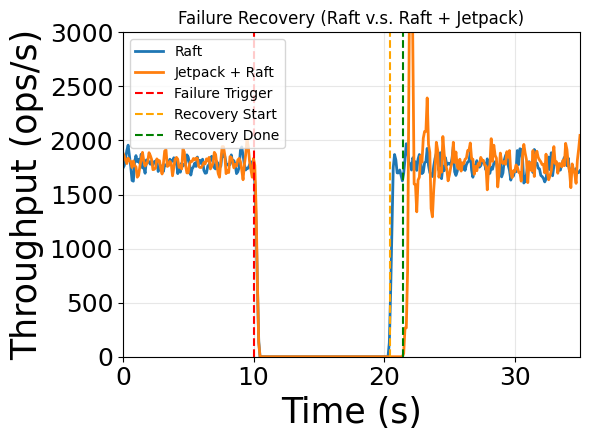

Downtime (Jetpack + MongoDB): 1580 ms


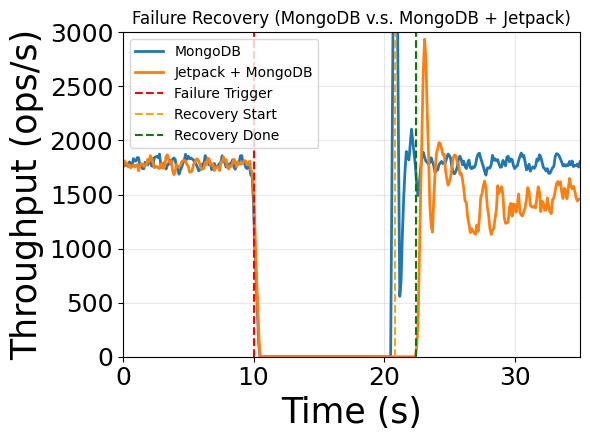

In [704]:
# Jetpack Failure Recovery Overlay (time-throughput only, aligned @10s)
# Pairs: base vs jetpack for raft and mongodb

PAIR_OVERLAYS = [
    ("raft-failure-recovery", "jetpack-raft-failure-recovery", "raft-vs-jetpack"),
    ("mongodb-failure-recovery", "jetpack-mongodb-failure-recovery", "mongodb-vs-jetpack"),
]

TITLE_OVERRIDES = {
    "raft-vs-jetpack": "Failure Recovery (Raft v.s. Raft + Jetpack)",
    "mongodb-vs-jetpack": "Failure Recovery (MongoDB v.s. MongoDB + Jetpack)",
}

LABEL_OVERRIDES = {
    "raft-vs-jetpack": ("Raft", "Jetpack + Raft"),
    "mongodb-vs-jetpack": ("MongoDB", "Jetpack + MongoDB"),
}

ALIGN_TO_SECONDS = 10.0  # shift so failure trigger aligns at 10s
X_RANGE = (0.0, 35.0)
Y_RANGE = (0.0, 3000.0)

os.makedirs("figs", exist_ok=True)


def clean_label(exp):
    return exp.replace("-failure-recovery", "")


def build_series(exp, align_to=10.0):
    data = jetpack_failure_recovery_data[exp]
    dt_all = data["dt"]
    te_all = data["te"]

    settings = FAILURE_RECOVERY_OVERRIDES.get(exp, {})
    filter_recovery_window = settings.get("filter_recovery_window", DEFAULT_FILTER_RECOVERY_WINDOW)
    window_s = settings.get("window_s", WINDOW_S_DEFAULT)
    include_latency = settings.get("include_latency", True)
    step_s = settings.get("step_s", STEP_S)

    num_dcs = len(dt_all)

    all_dt_arrays = [np.asarray(dt_all[i], dtype=float) for i in range(num_dcs) if len(dt_all[i]) > 0]
    if not all_dt_arrays:
        print(f"No dispatch data for {exp}, skipping.")
        return None

    global_dt_min_ms = min(arr.min() for arr in all_dt_arrays)
    failure_time_ms = data.get("failure_time")
    jetpack_recovery_begin_time_ms = data.get("jetpack_recovery_begin_time")
    jetpack_recovery_end_time_ms = data.get("jetpack_recovery_end_time")

    def to_relative_seconds(ms_val):
        if ms_val is None:
            return None
        return (ms_val - global_dt_min_ms) / 1000.0

    failure_time_s = to_relative_seconds(failure_time_ms)
    jetpack_recovery_begin_time_s = to_relative_seconds(jetpack_recovery_begin_time_ms)
    jetpack_recovery_end_time_s = to_relative_seconds(jetpack_recovery_end_time_ms)

    finish_times_by_dc = []
    dispatch_times_by_dc = []

    for i in range(num_dcs):
        dt_i = np.asarray(dt_all[i], dtype=float)
        te_i = np.asarray(te_all[i], dtype=float)
        n = min(len(dt_i), len(te_i))
        dt_i = dt_i[:n]
        te_i = te_i[:n]
        dt_i = dt_i - global_dt_min_ms
        if filter_recovery_window and failure_time_s is not None and jetpack_recovery_end_time_s is not None:
            dt_i_s_tmp = dt_i / 1000.0
            keep_mask = (dt_i_s_tmp < failure_time_s) | (dt_i_s_tmp > jetpack_recovery_end_time_s)
            dt_i = dt_i[keep_mask]
            te_i = te_i[:n][keep_mask]
        dt_i_s = dt_i / 1000.0
        dispatch_times_by_dc.append(dt_i_s)
        ft_i_ms = dt_i + te_i if include_latency else dt_i
        ft_i_s = ft_i_ms / 1000.0
        finish_times_by_dc.append(ft_i_s)

    dispatch_times_global = np.concatenate(dispatch_times_by_dc)
    dispatch_times_global.sort()
    finish_times_global = np.concatenate(finish_times_by_dc)
    finish_times_global.sort()

    # Align failure trigger to align_to
    align_shift = 0.0
    if align_to is not None and failure_time_s is not None:
        align_shift = align_to - failure_time_s
        dispatch_times_global = dispatch_times_global + align_shift
        finish_times_global = finish_times_global + align_shift
        dispatch_times_by_dc = [arr + align_shift for arr in dispatch_times_by_dc]
        finish_times_by_dc = [arr + align_shift for arr in finish_times_by_dc]
        failure_time_s = align_to
        if jetpack_recovery_begin_time_s is not None:
            jetpack_recovery_begin_time_s += align_shift
        if jetpack_recovery_end_time_s is not None:
            jetpack_recovery_end_time_s += align_shift

    t0_plot = finish_times_global.min() if X_RANGE[0] is None else max(finish_times_global.min(), X_RANGE[0])
    t1_plot = finish_times_global.max() if X_RANGE[1] is None else min(finish_times_global.max(), X_RANGE[1])

    ts = make_time_grid(finish_times_global, step_s=step_s, t0=t0_plot, t1=t1_plot)

    if PLOT_GLOBAL:
        thr_global = throughput_on_grid(finish_times_global, ts, window_s=window_s)
    else:
        thr_global = None

    markers = [
        ("Failure Trigger", failure_time_s, "red"),
        ("Recovery Start", jetpack_recovery_begin_time_s, "orange"),
        ("Recovery Done", jetpack_recovery_end_time_s, "green"),
    ]

    downtime_ms = None
    if jetpack_recovery_begin_time_ms is not None and jetpack_recovery_end_time_ms is not None:
        downtime_ms = jetpack_recovery_end_time_ms - jetpack_recovery_begin_time_ms

    return {
        "exp": exp,
        "ts": ts,
        "thr_global": thr_global,
        "t0": t0_plot,
        "t1": t1_plot,
        "markers": markers,
        "downtime_ms": downtime_ms,
    }

for base_exp, jetpack_exp, label in PAIR_OVERLAYS:
    series_list = []
    for exp in (base_exp, jetpack_exp):
        if exp not in jetpack_failure_recovery_data:
            print(f"Missing data for {exp}, skipping pair {label}")
            series_list = []
            break
        series = build_series(exp, align_to=ALIGN_TO_SECONDS)
        if series:
            series_list.append(series)
    if len(series_list) != 2:
        continue

    t0_plot = min(s["t0"] for s in series_list)
    t1_plot = max(s["t1"] for s in series_list)

    plt.figure(figsize=(6, 4.5))
    line_labels = LABEL_OVERRIDES.get(label, (clean_label(series_list[0]['exp']), clean_label(series_list[1]['exp'])))
    title_txt = TITLE_OVERRIDES.get(label, f"Failure Recovery Overlay ({label})")

    jetpack_downtime_ms = series_list[1].get("downtime_ms")
    if jetpack_downtime_ms is not None:
        print(f"Downtime ({line_labels[1]}): {jetpack_downtime_ms:.0f} ms")

    for idx_s, series in enumerate(series_list):
        series_label = line_labels[idx_s]
        if PLOT_GLOBAL and series["thr_global"] is not None:
            plt.plot(series["ts"], series["thr_global"], label=series_label, linewidth=2)
        # Only show markers for jetpack (assume second in pair)
        if idx_s == 1:
            for label_m, x_m, color_m in series["markers"]:
                if x_m is None:
                    continue
                if x_m < t0_plot or x_m > t1_plot:
                    continue
                plt.axvline(x_m, color=color_m, linestyle="--", linewidth=1.5, label=label_m)
            # if series.get("downtime_ms") is not None:
            #     plt.text(t0_plot + 0.5, Y_RANGE[1] * 0.9, f"Downtime: {series['downtime_ms']:.0f} ms", fontsize=12, color="black")

    plt.xlabel("Time (s)", fontsize=25)
    plt.ylabel("Throughput (ops/s)", fontsize=25)
    plt.title(title_txt)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.xlim(t0_plot, t1_plot)
    plt.ylim(Y_RANGE[0], Y_RANGE[1])
    overlay_fig = os.path.join(target_folder, f"{site_tag}_failure-recovery-{label}.pdf")
    plt.savefig(overlay_fig, bbox_inches="tight")
    plt.show()
    # print(f"Saved {overlay_fig}")


total finished ops (zoo) = 35989
time span (s): 0.1057048 to 30.052131934000002


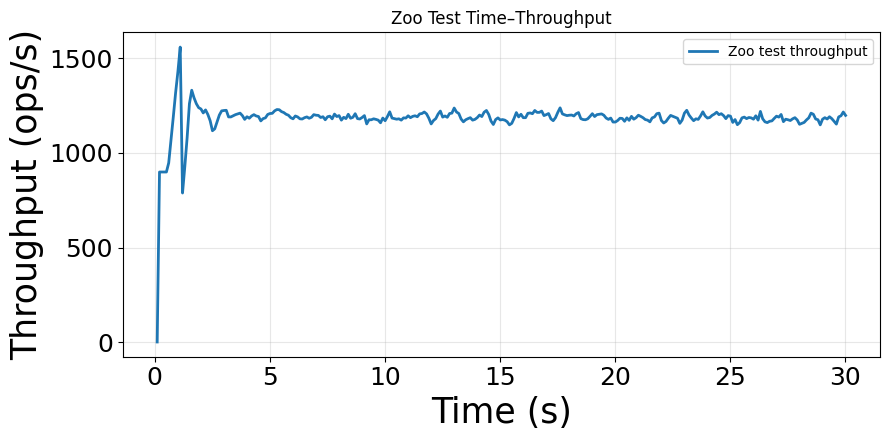

In [157]:
csv_path = "/home/users/ztang/JetPack-Scripts/results/2025-11-20-16:57:30-3613aeeba02ae7c1af0de4969493264d9e67d55d/zoo-test.csv"

# 1) Read CSV
df = pd.read_csv(csv_path)

# 2) Build finish times in *seconds*
#    Both Start-Time and End2End-Latency are in ms.
start_ms    = df["Start-Time"].to_numpy(dtype=float)
latency_ms  = df["End2End-Latency"].to_numpy(dtype=float)

finish_times_ms = start_ms + latency_ms
finish_times_zoo = finish_times_ms / 1000.0    # -> seconds, to match your other code

# Drop NaNs just in case
finish_times_zoo = finish_times_zoo[np.isfinite(finish_times_zoo)]
finish_times_zoo.sort()

print("total finished ops (zoo) =", len(finish_times_zoo))
print("time span (s):", finish_times_zoo[0], "to", finish_times_zoo[-1])

# 3) Make grid & compute sliding-window throughput
WINDOW_S = 1.0
STEP_S   = 0.1

# Uses make_time_grid and throughput_on_grid defined earlier in your notebook
ts_zoo  = make_time_grid(finish_times_zoo, step_s=STEP_S)
thr_zoo = throughput_on_grid(finish_times_zoo, ts_zoo, window_s=WINDOW_S)

# 4) Plot
plt.figure(figsize=(9, 4.5))

plt.plot(ts_zoo, thr_zoo, label="Zoo test throughput", linewidth=2)

plt.xlabel("Time (s)", fontsize=25)
plt.ylabel("Throughput (ops/s)", fontsize=25)
plt.title("Zoo Test Time–Throughput")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

*Everything below is not used*

